# 🧠 Federated Stress Detection — Model Comparison (Wrist)
## CNN · CNN-LSTM · CNN-LSTM-Attn · HAFN · MSTCN (Proposed)
### WESAD Wrist Dataset · Flower FL · Chronological 80/20 Split

---

### Models compared in this notebook

| Model | Type | Key idea |
|---|---|---|
| **CNN** | Baseline | 1-D convolutions, global average pooling |
| **CNN-LSTM** | Baseline | CNN extracts local features → BiLSTM models sequence |
| **CNN-LSTM-Attn** | Baseline | CNN-LSTM + scaled dot-product cross-modal attention |
| **HAFN** | ★ Proposed | Hierarchical Attention Fusion Network (3-level) |
| **MSTCN** | Becnhmark | Multi-Scale TCN: 4 branches {3,7,15,31} + SE + TemporalCtx |

All models trained with **Federated Learning** across 15 WESAD subjects (clients).  
FL strategies evaluated: **FedAvg · FedProx · CFL · FedNova** (20 experiments total).

**Dataset**: WESAD Wrist (Empatica E4) — BVP, EDA, ACC(×3), TEMP → 6 channels  
**Preprocessing**: 30s windows, 0% overlap, chronological 80/20 split, resampled to 4 Hz

In [ ]:
# !pip install "protobuf>=4.21.0,<5.0.0"
# !pip install "ray==2.31.0"
# !pip install "flwr==1.10.0"

## Cell 1 — Setup & Global Constants

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — SETUP & GLOBAL CONSTANTS (WRIST — Empatica E4)                ║
# ╚══════════════════════════════════════════════════════════════════════════╝

from google.colab import drive
drive.mount('/content/drive')

import os, pickle, random, math, copy, time, warnings
import numpy as np
import pandas as pd
from collections import Counter
from typing import Dict, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from scipy import signal as scipy_signal

import flwr as fl
from flwr.common import NDArrays, parameters_to_ndarrays, ndarrays_to_parameters
from flwr.server.strategy import FedAvg, FedProx
from flwr.simulation import start_simulation

import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
try:    plt.style.use('seaborn-v0_8-paper')
except: plt.style.use('seaborn-paper')
plt.rcParams.update({'font.size': 11, 'axes.titleweight': 'bold',
                     'figure.dpi': 100, 'savefig.dpi': 200})

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥  Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU    : {torch.cuda.get_device_name(0)}')
    print(f'   Memory : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('   ⚠️  No GPU → Runtime → Change runtime type → T4 GPU')
print(f'   Flower : {fl.__version__}')

DRIVE_DIR   = '/content/drive/MyDrive/HAFN_FL_SV'
PREPROC_DIR = os.path.join(DRIVE_DIR, 'preprocessed_wrist_v9')
RESULTS_DIR = os.path.join(DRIVE_DIR, 'results_wrist_comparison')
for d in [DRIVE_DIR, PREPROC_DIR, RESULTS_DIR]: os.makedirs(d, exist_ok=True)

# WESAD wrist (Empatica E4) — column order after resampling:
# [BVP(0), EDA(1), ACC_X(2), ACC_Y(3), ACC_Z(4), TEMP(5)]
ALL_SUBJECTS = ['S2','S3','S4','S5','S6','S7','S8','S9',
                'S10','S11','S13','S14','S15','S16','S17']
NUM_CLIENTS  = len(ALL_SUBJECTS)
LABEL_MAP    = {1: 0, 2: 1, 3: 0, 4: 0}
CLASS_NAMES  = ['Not-Stress', 'Stress']
LABEL_HZ     = 700

TARGET_HZ    = 4
WINDOW_SEC   = 30
STRIDE_SEC   = WINDOW_SEC
WINDOW_STEPS = WINDOW_SEC * TARGET_HZ   # 120 timesteps
STRIDE_STEPS = STRIDE_SEC * TARGET_HZ   # 120 timesteps
NUM_CHANNELS = 6

N_ROUNDS = 15; LOCAL_EP = 2; LR = 1e-3; BATCH_SIZE = 32
PREPROC_SUFFIX = 'wrist_chrono_v9'

print(f'\n📡 Wrist Config (Empatica E4):')
print(f'   Channels     : BVP, EDA, ACC_X, ACC_Y, ACC_Z, TEMP  ({NUM_CHANNELS}ch)')
print(f'   Target Hz    : {TARGET_HZ}')
print(f'   Window       : {WINDOW_SEC}s = {WINDOW_STEPS} timesteps  (0% overlap, 80/20 split)')
print(f'   Clients      : {NUM_CLIENTS}  |  Rounds: {N_ROUNDS}  |  LocalEP: {LOCAL_EP}')
print('\n✅ Cell 1 complete.')


Mounted at /content/drive
🖥  Device : cuda
   GPU    : Tesla T4
   Memory : 15.6 GB
   Flower : 1.10.0

📡 Wrist Config (Empatica E4):
   Channels     : BVP, EDA, ACC_X, ACC_Y, ACC_Z, TEMP  (6ch)
   Target Hz    : 4
   Window       : 30s = 120 timesteps  (0% overlap, 80/20 split)
   Clients      : 15  |  Rounds: 15  |  LocalEP: 2

✅ Cell 1 complete.


## Cell 2 — Dataset Download & Wrist Signal Extraction

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — DATASET EXTRACTION & WRIST SIGNAL LOADING                    ║
# ║  Source : /content/drive/MyDrive/archive (1).zip  (uploaded manually)  ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import zipfile

ZIP_PATH   = '/content/drive/MyDrive/archive (1).zip'
EXTRACT_TO = '/content/WESAD_extracted'

# ── Unzip once per Colab session (skip if already extracted) ─────────────────
if not os.path.isdir(os.path.join(EXTRACT_TO, 'WESAD')):
    print(f'📦 Extracting {ZIP_PATH} → {EXTRACT_TO} …')
    os.makedirs(EXTRACT_TO, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_TO)
    print('✅ Extraction complete.')
else:
    print('✅ Already extracted — skipping unzip.')

WESAD_PATH = os.path.join(EXTRACT_TO, 'WESAD')
print(f'   WESAD_PATH : {WESAD_PATH}')
# Sanity-check: list subject folders found
found = sorted([d for d in os.listdir(WESAD_PATH)
                if os.path.isdir(os.path.join(WESAD_PATH, d)) and d.startswith('S')])
print(f'   Subjects found : {found}\n')

# ── Signal helpers ────────────────────────────────────────────────────────────
def resample_1d(arr, orig_hz, target_hz):
    if orig_hz == target_hz: return arr
    return scipy_signal.resample(arr, int(len(arr) * target_hz / orig_hz))

def resample_2d(arr, orig_hz, target_hz):
    if orig_hz == target_hz: return arr
    n_new = int(arr.shape[0] * target_hz / orig_hz)
    return np.column_stack([scipy_signal.resample(arr[:, c], n_new)
                             for c in range(arr.shape[1])])

def load_wrist_signals(subject_id):
    pkl_path = os.path.join(WESAD_PATH, subject_id, f'{subject_id}.pkl')
    with open(pkl_path, 'rb') as f: data = pickle.load(f, encoding='latin1')
    wrist = data['signal']['wrist']; labels = data['label']
    BVP  = resample_1d(wrist['BVP'].reshape(-1),  64, TARGET_HZ)
    EDA  = resample_1d(wrist['EDA'].reshape(-1),   4, TARGET_HZ)
    ACC  = resample_2d(wrist['ACC'],              32, TARGET_HZ)
    TEMP = resample_1d(wrist['TEMP'].reshape(-1),  4, TARGET_HZ)
    LBL  = np.round(resample_1d(labels.astype(float), LABEL_HZ, TARGET_HZ)).astype(int)
    N = min(len(BVP), len(EDA), ACC.shape[0], len(TEMP), len(LBL))
    return np.column_stack([BVP[:N], EDA[:N], ACC[:N], TEMP[:N]]).astype(np.float32), LBL[:N]

def extract_windows_chronological(X, labels):
    windows, ys = [], []
    for start in range(0, len(labels) - WINDOW_STEPS + 1, STRIDE_STEPS):
        end = start + WINDOW_STEPS
        lbl = Counter(labels[start:end]).most_common(1)[0][0]
        if lbl not in LABEL_MAP: continue
        windows.append(X[start:end]); ys.append(LABEL_MAP[lbl])
    return np.array(windows, dtype=np.float32), np.array(ys, dtype=np.int64)

X_s2, lbl_s2 = load_wrist_signals('S2')
Xw_s2, yw_s2 = extract_windows_chronological(X_s2, lbl_s2)
print(f'  S2 raw shape : {X_s2.shape}  →  windows: {Xw_s2.shape}  labels: {dict(Counter(yw_s2.tolist()))}')
print('\n✅ Cell 2 complete.')


📦 Extracting /content/drive/MyDrive/archive (1).zip → /content/WESAD_extracted …
✅ Extraction complete.
   WESAD_PATH : /content/WESAD_extracted/WESAD
   Subjects found : ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']

  S2 raw shape : (24316, 6)  →  windows: (96, 120, 6)  labels: {0: 76, 1: 20}

✅ Cell 2 complete.


## Cell 3 — Non-Overlapping Chronological Preprocessing (v8)

In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — PREPROCESSING · 0% overlap · chronological 80/20 split       ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

def chrono_split_and_scale(X, y, sid, train_frac=0.8, min_stress_test=10):
    n = len(y)
    n_train = int(n * train_frac)
    X_tr, y_tr = X[:n_train].copy(), y[:n_train].copy()
    X_te, y_te = X[n_train:].copy(), y[n_train:].copy()
    n_stress_te = int((y_te == 1).sum())
    if n_stress_te < min_stress_test:
        needed = min_stress_test - n_stress_te
        stress_idx_tr = np.where(y_tr == 1)[0]
        if len(stress_idx_tr) == 0: return None
        move = stress_idx_tr[-min(needed, len(stress_idx_tr)):]
        X_te = np.concatenate([X_tr[move], X_te])
        y_te = np.concatenate([y_tr[move], y_te])
        X_tr = np.delete(X_tr, move, axis=0)
        y_tr = np.delete(y_tr, move)
    assert 1 in y_tr and 0 in y_tr, f'{sid}: train single-class!'
    assert 1 in y_te and 0 in y_te, f'{sid}: test single-class!'
    for ch in range(X_tr.shape[2]):
        sc = StandardScaler()
        flat_tr = X_tr[:, :, ch].reshape(-1, 1)
        sc.fit(flat_tr)
        X_tr[:, :, ch] = sc.transform(flat_tr).reshape(X_tr.shape[0], X_tr.shape[1])
        X_te[:, :, ch] = sc.transform(X_te[:, :, ch].reshape(-1,1)).reshape(X_te.shape[0], X_te.shape[1])
    return X_tr, y_tr, X_te, y_te

def oversample_minority(X, y, seed=SEED):
    classes, counts = np.unique(y, return_counts=True)
    if len(classes) < 2: return X, y
    max_c = min(counts.max(), int(counts.min() * 1.5))
    rng = np.random.default_rng(seed)
    Xs, Ys = [X], [y]
    for cls, cnt in zip(classes, counts):
        if cnt < max_c:
            idx = np.where(y == cls)[0]
            ext = rng.choice(idx, size=max_c - cnt, replace=True)
            Xs.append(X[ext]); Ys.append(y[ext])
    X_b = np.concatenate(Xs); y_b = np.concatenate(Ys)
    p = rng.permutation(len(y_b))
    return X_b[p], y_b[p]

def preprocess_subject(sid):
    X, y = load_wrist_signals(sid)
    Xw, yw = extract_windows_chronological(X, y)
    if len(np.unique(yw)) < 2:
        raise ValueError(f'{sid}: single class')
    result = chrono_split_and_scale(Xw, yw, sid)
    if result is None:
        raise ValueError(f'{sid}: no stress windows')
    X_tr, y_tr, X_te, y_te = result
    X_tr_b, y_tr_b = oversample_minority(X_tr, y_tr)
    cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_tr_b)
    cw = cw / cw.max()
    return {'X_train': X_tr_b.astype(np.float32), 'X_test': X_te.astype(np.float32),
            'y_train': y_tr_b.astype(np.int64),   'y_test': y_te.astype(np.int64),
            'n_raw': len(yw), 'class_weights': cw}

print('-'*70)
print('PROCESSING ALL 15 SUBJECTS')
print('-'*70)
stats_rows, skipped = [], []
for subj in ALL_SUBJECTS:
    path = os.path.join(PREPROC_DIR, f'{subj}_chrono_v8.pkl')
    if os.path.exists(path):
        with open(path, 'rb') as f: d = pickle.load(f)
        tag = 'cache'
    else:
        try:
            d = preprocess_subject(subj)
            with open(path, 'wb') as f: pickle.dump(d, f, protocol=pickle.HIGHEST_PROTOCOL)
            tag = 'new'
        except Exception as e:
            print(f'  [SKIP] {subj}: {e}'); skipped.append(subj); continue
    n_tr = len(d['y_train']); n_te = len(d['y_test'])
    s_tr = int((d['y_train']==1).sum()); s_te = int((d['y_test']==1).sum())
    print(f'  {subj:<4} [{tag}]  raw={d["n_raw"]:3d}  train={n_tr:4d}(S={s_tr})  test={n_te:3d}(S={s_te})')
    stats_rows.append({'Subject':subj,'Train':n_tr,'Test':n_te,'Stress_tr':s_tr,'Stress_te':s_te})

df_preproc = pd.DataFrame(stats_rows)
print(f'\n  Total train: {df_preproc.Train.sum()}  Total test: {df_preproc.Test.sum()}')
if skipped: print(f'  Skipped: {skipped}')
print('\n✅ Cell 3 complete.')


----------------------------------------------------------------------
PROCESSING ALL 15 SUBJECTS
----------------------------------------------------------------------
  S2   [new]  raw= 96  train=  71(S=15)  test= 30(S=10)
  S3   [new]  raw= 98  train=  73(S=16)  test= 30(S=10)
  S4   [new]  raw= 98  train=  81(S=18)  test= 23(S=10)
  S5   [new]  raw=101  train=  84(S=18)  test= 23(S=10)
  S6   [new]  raw=100  train=  76(S=18)  test= 30(S=10)
  S7   [new]  raw=100  train=  83(S=18)  test= 23(S=10)
  S8   [new]  raw=100  train=  83(S=18)  test= 23(S=10)
  S9   [new]  raw=101  train=  76(S=18)  test= 31(S=10)
  S10  [new]  raw=103  train=  87(S=22)  test= 23(S=10)
  S11  [new]  raw=100  train=  76(S=18)  test= 30(S=10)
  S13  [new]  raw=101  train=  84(S=18)  test= 23(S=10)
  S14  [new]  raw=100  train=  76(S=19)  test= 30(S=10)
  S15  [new]  raw=100  train=  83(S=19)  test= 23(S=10)
  S16  [new]  raw=101  train=  76(S=19)  test= 31(S=10)
  S17  [new]  raw= 99  train=  83(S=21)  test= 

## Cell 4 — All Model Architectures

### Architecture Summary

| Model | Architecture | Parameters (approx) |
|---|---|---|
| **CNN** | Conv1d×3 → AvgPool → MLP | ~50K |
| **CNN-LSTM** | Conv1d×2 → BiLSTM → MLP | ~120K |
| **CNN-LSTM-Attn** | Per-modality CNN-BiLSTM → Scaled Dot-Product Attention → MLP | ~300K |
| **HAFN** | Per-modality BiLSTM+PE+Attn → Motion Gate → Cross-Modal Attn → FFT+Stats → MLP | ~450K |

All models use **InstanceNorm** (not BatchNorm) — FL-safe for federated aggregation.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — MODEL ARCHITECTURES                                           ║
# ║  CNN · CNN-LSTM · CNN-LSTM-Attn · HAFN                                  ║
# ╚══════════════════════════════════════════════════════════════════════════╝


# ═════════════════════════════════════════════════════════════════════════════
# MODEL 1: CNN (Baseline)
# ─────────────────────────────────────────────────────────────────────────────
# Simplest baseline. Three Conv1d layers extract local temporal patterns
# across all 6 channels jointly. Global average pooling collapses the time
# dimension into a fixed vector. No sequential modelling — treats each
# timestep independently.
# ═════════════════════════════════════════════════════════════════════════════

class CNN(nn.Module):
    """
    1-D Temporal CNN Baseline.
    Input  : (B, T=120, C=6)
    Output : (B, 2) logits
    """
    def __init__(self, in_ch=NUM_CHANNELS, dropout=0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            # Block 1: local short-term patterns (~0.75s at 4Hz)
            nn.Conv1d(in_ch, 64, kernel_size=7, padding=3),
            nn.InstanceNorm1d(64, affine=True),   # FL-safe norm
            nn.ReLU(),
            nn.Dropout(0.1),

            # Block 2: medium-term patterns
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.InstanceNorm1d(128, affine=True),
            nn.ReLU(),
            nn.Dropout(0.1),

            # Block 3: higher-level abstractions
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.InstanceNorm1d(256, affine=True),
            nn.ReLU(),

            # Collapse time dimension → (B, 256, 1)
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 2),
        )

    def forward(self, x, return_attention=False):
        # x: (B, T, C) → permute to (B, C, T) for Conv1d
        return self.classifier(self.encoder(x.permute(0, 2, 1)))


# ═════════════════════════════════════════════════════════════════════════════
# MODEL 2: CNN-LSTM (Baseline)
# ─────────────────────────────────────────────────────────────────────────────
# Hybrid: CNN extracts local features first, then BiLSTM models the temporal
# sequence of those features. Captures both local patterns (CNN) and long-range
# dependencies (LSTM). Standard strong baseline for time-series classification.
# ═════════════════════════════════════════════════════════════════════════════

class CNN_LSTM(nn.Module):
    """
    CNN local feature extraction → BiLSTM temporal modelling.
    Input  : (B, T=120, C=6)
    Output : (B, 2) logits
    """
    def __init__(self, in_ch=NUM_CHANNELS, hidden=64, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_ch, 64, kernel_size=7, padding=3),
            nn.InstanceNorm1d(64, affine=True),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.InstanceNorm1d(64, affine=True),
            nn.ReLU(),
        )
        # BiLSTM: reads CNN feature sequence both forward and backward
        self.lstm = nn.LSTM(64, hidden, num_layers=2, batch_first=True,
                            bidirectional=True, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 2),
        )

    def forward(self, x, return_attention=False):
        # CNN stage
        h = self.cnn(x.permute(0, 2, 1))    # (B, 64, T)
        h = h.permute(0, 2, 1)              # (B, T, 64)
        # BiLSTM stage — take last timestep hidden state
        out, _ = self.lstm(h)
        return self.classifier(out[:, -1, :])


# ═════════════════════════════════════════════════════════════════════════════
# MODEL 3: CNN-LSTM-Attention (Baseline)
# ─────────────────────────────────────────────────────────────────────────────
# Extends CNN-LSTM by adding cross-modal attention fusion.
# Each modality (BVP, EDA, ACC, TEMP) gets its own CNN-BiLSTM encoder,
# then the 4 modality embeddings interact via scaled dot-product attention.
# This lets the model learn which sensors are most informative per window.
# ═════════════════════════════════════════════════════════════════════════════

class _ModalityCNNLSTM(nn.Module):
    """One CNN-BiLSTM encoder for a single modality."""
    def __init__(self, in_ch, hidden, dropout=0.2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=7, padding=3),
            nn.InstanceNorm1d(32, affine=True),
            nn.ReLU(), nn.MaxPool1d(2),           # 120→60
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.InstanceNorm1d(64, affine=True),
            nn.ReLU(), nn.MaxPool1d(2),           # 60→30
        )
        self.lstm = nn.LSTM(64, hidden, batch_first=True, bidirectional=True)
        self.proj = nn.Sequential(
            nn.Linear(hidden * 2, hidden), nn.GELU(), nn.Dropout(dropout))

    def forward(self, x):
        h = self.cnn(x.permute(0, 2, 1)).permute(0, 2, 1)   # (B, 30, 64)
        _, (h_n, _) = self.lstm(h)
        return self.proj(torch.cat([h_n[0], h_n[1]], dim=-1))  # (B, hidden)


class CNN_LSTM_Attention(nn.Module):
    """
    Per-modality CNN-BiLSTM + Scaled Dot-Product Cross-Modal Attention.

    Architecture:
      BVP(1ch) → CNN-LSTM → h_bvp  (B, H)  ─┐
      EDA(1ch) → CNN-LSTM → h_eda  (B, H)   │  Stack (B,4,H)
      ACC(3ch) → CNN-LSTM → h_acc  (B, H)   │  → Q,K,V projections
      TEMP(1ch)→ CNN-LSTM → h_temp (B, H)  ─┘  → Attention
                                                 → mean pool → classifier

    Input  : (B, T=120, C=6)
    Output : (B, 2) logits
    """
    def __init__(self, hidden=128, dropout=0.3):
        super().__init__()
        H = hidden
        # Per-modality encoders — correct WESAD channel layout
        self.bvp_enc  = _ModalityCNNLSTM(1, H, dropout)
        self.eda_enc  = _ModalityCNNLSTM(1, H, dropout)
        self.acc_enc  = _ModalityCNNLSTM(3, H, dropout)
        self.temp_enc = _ModalityCNNLSTM(1, H, dropout)
        # Q, K, V projections
        self.q_proj = nn.Linear(H, H)
        self.k_proj = nn.Linear(H, H)
        self.v_proj = nn.Linear(H, H)
        self.scale  = math.sqrt(H)
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(H, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 2),
        )

    def forward(self, x, return_attention=False):
        # Split channels — WESAD wrist layout
        bvp  = x[:, :, 0:1]    # BVP
        eda  = x[:, :, 1:2]    # EDA
        acc  = x[:, :, 2:5]    # ACC X/Y/Z
        temp = x[:, :, 5:6]    # TEMP

        # Encode each modality
        h_bvp  = self.bvp_enc(bvp)
        h_eda  = self.eda_enc(eda)
        h_acc  = self.acc_enc(acc)
        h_temp = self.temp_enc(temp)

        # Stack → (B, 4, H)
        feats = torch.stack([h_bvp, h_eda, h_acc, h_temp], dim=1)

        # Scaled dot-product attention over modality axis
        Q = self.q_proj(feats)
        K = self.k_proj(feats)
        V = self.v_proj(feats)
        attn_w  = torch.softmax(torch.matmul(Q, K.transpose(-2,-1)) / self.scale, dim=-1)
        attn_out = torch.matmul(attn_w, V)   # (B, 4, H)

        # Mean pool over modalities → (B, H)
        fused  = attn_out.mean(dim=1)
        logits = self.classifier(fused)

        if return_attention:
            return logits, attn_w
        return logits


# ═════════════════════════════════════════════════════════════════════════════
# MODEL 4: HAFN — Hierarchical Attention Fusion Network (Proposed)
# ─────────────────────────────────────────────────────────────────────────────
# Three-level hierarchy:
#   Level 1 — Per-modality BiLSTM + Positional Encoding + Temporal Attention
#              (EDA gets 3 layers; BVP gets additional FFT HRV branch)
#   Level 2 — Motion Artifact Gate (ACC gates BVP & EDA)
#              + Cross-Modal Attention (4 modalities)
#   Level 3 — Concatenate: cross-modal + FFT HRV + Global Stats → Classifier
# All norms are InstanceNorm — FL-safe.
# ═════════════════════════════════════════════════════════════════════════════

class LearnedPositionalEncoding(nn.Module):
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.pe = nn.Embedding(seq_len, d_model)
        self.register_buffer('positions', torch.arange(seq_len).unsqueeze(0))
    def forward(self, x):
        return x + self.pe(self.positions)

class AttentionWeightedPool(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.Tanh(),
            nn.Linear(hidden // 2, 1))
    def forward(self, x):
        w = torch.softmax(self.score(x).squeeze(-1), dim=-1)
        return (x * w.unsqueeze(-1)).sum(dim=1), w

class TemporalSelfAttention(nn.Module):
    def __init__(self, hidden, n_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(hidden, n_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(hidden)
        self.pool = AttentionWeightedPool(hidden)
    def forward(self, x):
        out, _ = self.attn(x, x, x)
        out    = self.norm(out + x)
        pooled, w = self.pool(out)
        return pooled, w

class ModalityEncoder(nn.Module):
    """BiLSTM + Positional Encoding + Temporal Self-Attention for one modality."""
    def __init__(self, in_ch, hidden=64, n_layers=2, n_heads=4, drop=0.2, seq_len=WINDOW_STEPS):
        super().__init__()
        self.lstm = nn.LSTM(in_ch, hidden, n_layers, batch_first=True,
                            bidirectional=True,
                            dropout=drop if n_layers > 1 else 0.)
        self.proj = nn.Linear(hidden * 2, hidden)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(drop)
        self.pe   = LearnedPositionalEncoding(seq_len, hidden)
        self.attn = TemporalSelfAttention(hidden, n_heads, drop)
    def forward(self, x):
        h, _  = self.lstm(x)
        h     = self.drop(self.act(self.proj(h)))
        h     = self.pe(h)
        feat, w = self.attn(h)
        return feat, w

class CrossModalAttention(nn.Module):
    def __init__(self, hidden, n_heads=4, drop=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(hidden, n_heads, dropout=drop, batch_first=True)
        self.norm = nn.LayerNorm(hidden)
    def forward(self, x):
        out, w = self.attn(x, x, x)
        out    = self.norm(out + x)
        return out.reshape(out.size(0), -1), w

class MotionArtifactGate(nn.Module):
    """Gate BVP and EDA based on ACC norm — reduces motion artifact influence."""
    def __init__(self):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(1, 8), nn.ReLU(),
                                  nn.Linear(8, 1), nn.Sigmoid())
    def forward(self, acc):
        acc_norm = acc.norm(dim=-1, keepdim=True).mean(dim=1)
        return self.gate(acc_norm)

class BVPFrequencyBranch(nn.Module):
    """
    FFT HRV branch — extracts VLF, LF, HF band powers from BVP.
    These are clinically validated autonomic nervous system indicators
    (Task Force ESC/NASPE, Circulation 1996).
    """
    def __init__(self, seq_len=WINDOW_STEPS, target_hz=TARGET_HZ, fft_out=16):
        super().__init__()
        freqs = np.fft.rfftfreq(seq_len, d=1./target_hz)
        self.register_buffer('vlf_mask',
            torch.tensor((freqs >= 0.003) & (freqs < 0.04),  dtype=torch.float32))
        self.register_buffer('lf_mask',
            torch.tensor((freqs >= 0.04)  & (freqs < 0.15),  dtype=torch.float32))
        self.register_buffer('hf_mask',
            torch.tensor((freqs >= 0.15)  & (freqs < 0.40),  dtype=torch.float32))
        self.fc = nn.Sequential(nn.Linear(3, 16), nn.ReLU(), nn.Linear(16, fft_out))
    def forward(self, bvp):
        x     = bvp.squeeze(-1)
        spec  = torch.fft.rfft(x, dim=-1)
        power = spec.abs() ** 2
        total = (power * self.vlf_mask).sum(-1,keepdim=True)+(power * self.lf_mask ).sum(-1,keepdim=True)+(power * self.hf_mask ).sum(-1,keepdim=True)+1e-8
        vlf = (power * self.vlf_mask).sum(-1, keepdim=True) / total
        lf  = (power * self.lf_mask ).sum(-1, keepdim=True) / total
        hf  = (power * self.hf_mask ).sum(-1, keepdim=True) / total
        return self.fc(torch.cat([vlf, lf, hf], dim=-1))

class HAFN(nn.Module):
    """
    ╔══════════════════════════════════════════════════════════════════════╗
    ║  HAFN v4 — Hierarchical Attention Fusion Network (Proposed)         ║
    ╠══════════════════════════════════════════════════════════════════════╣
    ║  Level 1 — Intra-modal (per sensor):                                ║
    ║    BVP  : BiLSTM(2L) + PE + Temporal Attention                      ║
    ║    EDA  : BiLSTM(3L) + PE + Temporal Attention  ← deeper (slow)     ║
    ║    ACC  : BiLSTM(2L) + PE + Temporal Attention                      ║
    ║    TEMP : BiLSTM(2L) + PE + Temporal Attention                      ║
    ║                                                                      ║
    ║  Level 2 — Inter-modal:                                             ║
    ║    Motion Gate  : ACC norm gates BVP & EDA (motion artifact fix)    ║
    ║    Cross-Modal Attention : 4 modalities interact                    ║
    ║                                                                      ║
    ║  Level 3 — Classification:                                          ║
    ║    Cross-modal features + FFT HRV (16) + Global stats (18) → MLP   ║
    ║    InstanceNorm — FL-safe aggregation                               ║
    ╚══════════════════════════════════════════════════════════════════════╝
    Input  : (B, T=120, C=6)
    Output : (B, 2) logits
    """
    N_MOD = 4; FFT_OUT = 16; STAT_DIM = 18

    def __init__(self, hidden=64, n_layers=2, n_heads=4, dropout=0.3, n_classes=2):
        super().__init__()
        H = hidden
        # Level 1
        self.enc_bvp  = ModalityEncoder(1, H, n_layers,   n_heads, dropout)
        self.enc_eda  = ModalityEncoder(1, H, n_layers+1, n_heads, dropout)  # 3 layers
        self.enc_acc  = ModalityEncoder(3, H, n_layers,   n_heads, dropout)
        self.enc_temp = ModalityEncoder(1, H, n_layers,   n_heads, dropout)
        # Level 2
        self.motion_gate = MotionArtifactGate()
        self.cross       = CrossModalAttention(H, n_heads, dropout)
        # Auxiliary branches
        self.bvp_fft   = BVPFrequencyBranch(fft_out=self.FFT_OUT)
        self.stat_proj = nn.Sequential(nn.Linear(self.STAT_DIM, 32), nn.GELU(),
                                       nn.Linear(32, H // 2))
        # Level 3
        fused = H * self.N_MOD + self.FFT_OUT + H // 2
        self.clf = nn.Sequential(
            nn.InstanceNorm1d(1),
            nn.Flatten(),
            nn.Linear(fused, fused // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(fused // 2, fused // 4), nn.GELU(), nn.Dropout(dropout / 2),
            nn.Linear(fused // 4, n_classes))

    def _global_stats(self, x):
        mu  = x.mean(dim=1); sigma = x.std(dim=1)
        rng = x.max(dim=1).values - x.min(dim=1).values
        return torch.cat([mu, sigma, rng], dim=-1)

    def forward(self, x, return_attention=False):
        bvp  = x[:, :, [0]]; eda  = x[:, :, [1]]
        acc  = x[:, :, 2:5]; temp = x[:, :, [5]]
        # Level 1
        f_b, w_b = self.enc_bvp(bvp)
        f_e, w_e = self.enc_eda(eda)
        f_a, w_a = self.enc_acc(acc)
        f_t, w_t = self.enc_temp(temp)
        # Level 2 — motion gate
        gate = self.motion_gate(acc)
        f_b  = f_b * gate
        f_e  = f_e * gate
        # Level 2 — cross-modal attention
        stacked           = torch.stack([f_b, f_e, f_a, f_t], dim=1)
        fused_cross, w_c  = self.cross(stacked)
        # Auxiliary
        fft_feats = self.bvp_fft(bvp)
        stat_emb  = self.stat_proj(self._global_stats(x))
        # Level 3
        combined = torch.cat([fused_cross, fft_feats, stat_emb], dim=-1).unsqueeze(1)
        logits   = self.clf(combined)
        if return_attention:
            return logits, {'bvp':w_b,'eda':w_e,'acc':w_a,'temp':w_t,'cross':w_c,'gate':gate}
        return logits


# ── Model Registry ────────────────────────────────────────────────────────────

# ── MSTCN helper classes (Multi-Scale TCN components) ─────────────────────────

class DepthwiseSeparableConv1d(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel: int,
                 padding: int = 0, dilation: int = 1):
        super().__init__()
        pad = padding if padding >= 0 else ((kernel - 1) * dilation) // 2
        self.dw = nn.Conv1d(in_ch, in_ch, kernel, padding=pad,
                            dilation=dilation, groups=in_ch, bias=False)
        self.pw = nn.Conv1d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm1d(out_ch)

    def forward(self, x):
        return self.bn(self.pw(self.dw(x)))


class SqueezeExcite1d(nn.Module):
    def __init__(self, channels: int, reduction: int = 4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.pool(x).squeeze(-1)
        w = self.fc(w).unsqueeze(-1)
        return x * w


class MSBranch(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel: int, dilation: int = 1):
        super().__init__()
        pad = ((kernel - 1) * dilation) // 2
        self.conv1 = DepthwiseSeparableConv1d(in_ch,  out_ch, kernel,
                                               padding=pad, dilation=dilation)
        self.conv2 = DepthwiseSeparableConv1d(out_ch, out_ch, kernel,
                                               padding=pad, dilation=dilation)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(0.2)
        self.res  = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        h = self.drop(self.act(self.conv1(x)))
        h = self.conv2(h)
        return self.act(h + self.res(x))


class TemporalContextBlock(nn.Module):
    def __init__(self, channels: int, n_heads: int = 4):
        super().__init__()
        self.norm  = nn.LayerNorm(channels)
        self.attn  = nn.MultiheadAttention(channels, n_heads,
                                            batch_first=True, dropout=0.1)
        self.ff    = nn.Sequential(
            nn.Linear(channels, channels * 2), nn.GELU(),
            nn.Linear(channels * 2, channels))
        self.norm2 = nn.LayerNorm(channels)

    def forward(self, x):
        x      = x.permute(0, 2, 1)
        x_norm = self.norm(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return x.permute(0, 2, 1)


class MSTCN(nn.Module):
    """
    ╔══════════════════════════════════════════════════════════════╗
    ║  MSTCN — Multi-Scale Temporal Convolutional Network          ║
    ╠══════════════════════════════════════════════════════════════╣
    ║  Architecture:                                               ║
    ║  1. Multi-Scale Extraction (4 parallel branches)             ║
    ║     • Branch A: kernel=3,  dilation=1  → short-scale        ║
    ║     • Branch B: kernel=7,  dilation=1  → mid-scale          ║
    ║     • Branch C: kernel=15, dilation=2  → long-scale         ║
    ║     • Branch D: kernel=31, dilation=4  → full window         ║
    ║  2. Fusion: concatenate → pointwise projection               ║
    ║  3. Squeeze-and-Excite channel attention                     ║
    ║  4. Temporal Context Block (lightweight transformer)         ║
    ║  5. Global average pool → MLP classifier                     ║
    ╠══════════════════════════════════════════════════════════════╣
    ║  in_ch = 6  (BVP, EDA, ACC_X/Y/Z, TEMP)
    ╚══════════════════════════════════════════════════════════════╝
    Input  : (B, T=120, C=6)
    Output : (B, 2) logits
    """
    def __init__(self, in_ch: int = 6, base_ch: int = 48,
                 n_classes: int = 2, dropout: float = 0.3):
        super().__init__()
        B = base_ch
        self.branch_a = MSBranch(in_ch, B, kernel=3,  dilation=1)
        self.branch_b = MSBranch(in_ch, B, kernel=7,  dilation=1)
        self.branch_c = MSBranch(in_ch, B, kernel=15, dilation=2)
        self.branch_d = MSBranch(in_ch, B, kernel=31, dilation=4)
        self.fusion   = nn.Sequential(
            nn.Conv1d(B * 4, B * 2, 1),
            nn.BatchNorm1d(B * 2),
            nn.GELU()
        )
        self.se       = SqueezeExcite1d(B * 2, reduction=4)
        self.temporal = TemporalContextBlock(B * 2, n_heads=4)
        self.pool     = nn.AdaptiveAvgPool1d(1)
        self.drop     = nn.Dropout(dropout)
        self.head     = nn.Sequential(
            nn.Linear(B * 2, B), nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(B, n_classes)
        )

    def forward(self, x, return_attention: bool = False):
        xc    = x.permute(0, 2, 1)                              # (B, 6, T)
        a, b  = self.branch_a(xc), self.branch_b(xc)
        c, d  = self.branch_c(xc), self.branch_d(xc)
        fused = self.fusion(torch.cat([a, b, c, d], dim=1))
        fused = self.se(fused)
        fused = self.temporal(fused)
        pooled = self.pool(fused).squeeze(-1)
        return self.head(self.drop(pooled))

# ── Model Registry ────────────────────────────────────────────────────────────
MODEL_REGISTRY: Dict[str, Tuple] = {
    'CNN'          : (CNN,               dict(in_ch=NUM_CHANNELS)),
    'CNN-LSTM'     : (CNN_LSTM,          dict(in_ch=NUM_CHANNELS)),
    'CNN-LSTM-Attn': (CNN_LSTM_Attention, dict(hidden=128, dropout=0.3)),
    'HAFN'         : (HAFN,              dict(hidden=64, n_layers=2, n_heads=4, dropout=0.3)),
    'MSTCN'        : (MSTCN,             dict(in_ch=NUM_CHANNELS)),
}

def build_model(name): cls, kw = MODEL_REGISTRY[name]; return cls(**kw).to(DEVICE)
def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

# ── Verification ──────────────────────────────────────────────────────────────
print('🏗️  Model Verification')
print('─' * 76)
print(f'  {"Model":<18} {"Parameters":>12}  {"Output":>12}  Notes')
print('─' * 76)
dummy = torch.randn(4, WINDOW_STEPS, NUM_CHANNELS).to(DEVICE)
notes = {
    'CNN'          : 'Baseline',
    'CNN-LSTM'     : 'Baseline',
    'CNN-LSTM-Attn': 'Baseline',
    'HAFN'         : '★ PROPOSED',
    'MSTCN'        : '★ NOVEL PROPOSED',
}
for name in MODEL_REGISTRY:
    m = build_model(name)
    with torch.no_grad(): out = m(dummy)
    print(f'  {name:<18} {count_params(m):>12,}  {str(tuple(out.shape)):>12}  {notes.get(name,"")}')
print('─' * 76)
print('\n✅ Cell 4 complete — all models verified.')


🏗️  Model Verification
────────────────────────────────────────────────────────────────────────────
  Model                Parameters        Output  Notes
────────────────────────────────────────────────────────────────────────────
  CNN                     159,874        (4, 2)  Baseline
  CNN-LSTM                197,826        (4, 2)  Baseline
  CNN-LSTM-Attn         1,035,970        (4, 2)  Baseline
  HAFN                    851,083        (4, 2)  ★ PROPOSED
  MSTCN                   118,490        (4, 2)  ★ NOVEL PROPOSED
────────────────────────────────────────────────────────────────────────────

✅ Cell 4 complete — all models verified.


## Cell 5 — Flower Client, FL Strategies & Experiment Runner

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — FL INFRASTRUCTURE (identical across all models)               ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def safe_auroc(trues, probs):
    y_true = np.array(trues); y_prob = np.array(probs)
    if len(np.unique(y_true)) < 2: return np.nan
    try: return float(roc_auc_score(y_true, y_prob))
    except: return np.nan

def fmt_float(v, spec='.4f'):
    try:
        f = float(v)
        if f != f or f in (float('inf'), float('-inf')): return 'NaN'
        return format(f, spec)
    except: return 'NaN'

def load_client_data(cid, batch_size=BATCH_SIZE):
    subj = ALL_SUBJECTS[cid]
    with open(os.path.join(PREPROC_DIR, f'{subj}_chrono_v8.pkl'), 'rb') as f:
        d = pickle.load(f)
    tr = DataLoader(TensorDataset(torch.tensor(d['X_train']), torch.tensor(d['y_train'])),
                    batch_size=batch_size, shuffle=True, drop_last=True)
    te = DataLoader(TensorDataset(torch.tensor(d['X_test']),  torch.tensor(d['y_test'])),
                    batch_size=batch_size)
    return tr, te, d['class_weights']

def get_params(model):  return [v.cpu().numpy() for v in model.state_dict().values()]
def set_params(model, params):
    sd = model.state_dict()
    for k, arr in zip(sd.keys(), params): sd[k] = torch.tensor(arr)
    model.load_state_dict(sd); return model

def train_local(model, dl, cw, epochs=LOCAL_EP, lr=LR, mu=0., global_params=None):
    model.train()
    crit = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float32).to(DEVICE),
                                label_smoothing=0.1)
    opt = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = CosineAnnealingLR(opt, T_max=epochs)
    total = 0.
    for _ in range(epochs):
        ep = 0.
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            if mu > 0 and global_params is not None:
                prox = sum(((p-gp.detach())**2).sum()
                           for p, gp in zip(model.parameters(), global_params))
                loss = loss + (mu/2)*prox
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            for p in model.parameters():
                if p.grad is not None:
                    p.grad.data.add_(torch.randn_like(p.grad) * 5e-4)
            opt.step(); ep += loss.item()
        sch.step(); total += ep / len(dl)
    return total / epochs

@torch.no_grad()
def eval_model(model, dl):
    model.eval(); preds, probs, trues = [], [], []
    for xb, yb in dl:
        logits = model(xb.to(DEVICE))
        probs.extend(F.softmax(logits,-1)[:,1].cpu().numpy())
        preds.extend(logits.argmax(-1).cpu().numpy())
        trues.extend(yb.numpy())
    return {'acc': accuracy_score(trues, preds),
            'f1':  f1_score(trues, preds, average='macro', zero_division=0),
            'auroc': safe_auroc(trues, probs),
            'cm': confusion_matrix(trues, preds, labels=[0,1])}

class HAFNClient(fl.client.NumPyClient):
    def __init__(self, cid, model_name, mu=0., dp_eps=None, dp_delta=1e-5, dp_clip=1.):
        self.cid=cid; self.mu=mu; self.dp=dp_eps; self.delta=dp_delta; self.clip=dp_clip
        self.tr, self.te, self.cw = load_client_data(cid)
        self.n_train = len(self.tr.dataset)
        self.model   = build_model(model_name)
    def get_parameters(self, config): return get_params(self.model)
    def fit(self, params, config):
        set_params(self.model, params)
        gp   = list(self.model.parameters()) if self.mu > 0 else None
        loss = train_local(self.model, self.tr, self.cw, mu=self.mu, global_params=gp)
        if self.dp is not None:
            sigma = self.clip * math.sqrt(2*math.log(1.25/self.delta)) / self.dp
            pnames = {n for n,_ in self.model.named_parameters()}
            sd = self.model.state_dict()
            for k,v in sd.items():
                if k in pnames and v.is_floating_point():
                    sd[k] = v + torch.randn_like(v)*sigma
            self.model.load_state_dict(sd)
        tau = float(LOCAL_EP * max(1, len(self.tr)))
        return get_params(self.model), self.n_train, {'loss':float(loss),'tau':tau}
    def evaluate(self, params, config):
        set_params(self.model, params); m = eval_model(self.model, self.te)
        return float(1-m['acc']), len(self.te.dataset), {'accuracy':m['acc'],'f1':m['f1'],'auroc':m['auroc']}

class FedNovaStrategy(FedAvg):
    def aggregate_fit(self, rnd, results, failures):
        if not results: return None, {}
        params_list = [parameters_to_ndarrays(r.parameters) for _,r in results]
        sizes = np.array([r.num_examples for _,r in results], dtype=float)
        taus  = np.array([r.metrics.get('tau',1.) for _,r in results], dtype=float)
        weights = sizes/sizes.sum(); mean_tau = float((weights*taus).sum())
        w_avg = [sum(weights[i]*params_list[i][l] for i in range(len(params_list)))
                 for l in range(len(params_list[0]))]
        deltas = [[(params_list[i][l]-w_avg[l])/max(taus[i],1e-8) for l in range(len(w_avg))]
                  for i in range(len(params_list))]
        d_agg  = [sum(weights[i]*deltas[i][l] for i in range(len(deltas))) for l in range(len(w_avg))]
        w_new  = [w_avg[l]+mean_tau*d_agg[l] for l in range(len(w_avg))]
        return ndarrays_to_parameters(w_new), {}

class CFLStrategy(FedAvg):
    def __init__(self, n_clusters=3, **kw): super().__init__(**kw); self.k=n_clusters
    @staticmethod
    def _cos(a,b):
        va=np.concatenate([x.flatten() for x in a]); vb=np.concatenate([x.flatten() for x in b])
        d=np.linalg.norm(va)*np.linalg.norm(vb)
        return float(np.dot(va,vb)/d) if d>0 else 0.
    def aggregate_fit(self, rnd, results, failures):
        if not results: return None,{}
        params=[parameters_to_ndarrays(r.parameters) for _,r in results]
        sizes=[int(r.num_examples) for _,r in results]
        n=len(params); k=int(min(self.k,n))
        sim=np.array([[self._cos(params[i],params[j]) for j in range(n)] for i in range(n)])
        cents=sorted(range(n),key=lambda i:sizes[i],reverse=True)[:k]
        clusters=[[c] for c in cents]; assigned=set(cents)
        for i in range(n):
            if i not in assigned:
                best=max(range(k),key=lambda c:sim[i,cents[c]]); clusters[best].append(i)
        c_aggs=[]
        for cl in clusters:
            if not cl: continue
            tot=sum(sizes[i] for i in cl)
            c_aggs.append([sum((sizes[i]/tot)*params[i][l] for i in cl) for l in range(len(params[0]))])
        agg=[sum(ca[l] for ca in c_aggs)/len(c_aggs) for l in range(len(params[0]))]
        return ndarrays_to_parameters(agg),{}

def make_history():
    return {'round':[],'global_acc':[],'global_f1':[],'global_auroc':[],
            'client_acc':[],'client_f1':[],'client_auroc':[]}

def make_strategy(strategy_name, model_name, mu=0.01, n_clusters=3):
    hist = make_history()
    def eval_fn(server_round, params, config):
        tmp=build_model(model_name); set_params(tmp, params)
        accs,f1s,aucs=[],[],[]
        for cid in range(NUM_CLIENTS):
            _,te_dl,_=load_client_data(cid); m=eval_model(tmp,te_dl)
            accs.append(m['acc']); f1s.append(m['f1']); aucs.append(m['auroc'])
        hist['round'].append(server_round)
        hist['global_acc'].append(float(np.mean(accs)))
        hist['global_f1'].append(float(np.mean(f1s)))
        hist['global_auroc'].append(float(np.nanmean(aucs)))
        hist['client_acc'].append(accs); hist['client_f1'].append(f1s); hist['client_auroc'].append(aucs)
        return float(1-np.mean(accs)), {'accuracy': np.mean(accs)}
    common = dict(fraction_fit=1., fraction_evaluate=0.,
                  min_fit_clients=NUM_CLIENTS, min_available_clients=NUM_CLIENTS,
                  evaluate_fn=eval_fn)
    mu_c = 0.
    if   strategy_name=='FedAvg':  strat=FedAvg(**common)
    elif strategy_name=='FedProx': strat=FedProx(proximal_mu=mu,**common); mu_c=mu
    elif strategy_name=='CFL':     strat=CFLStrategy(n_clusters,**common)
    elif strategy_name=='FedNova': strat=FedNovaStrategy(**common)
    else: raise ValueError(f'Unknown: {strategy_name}')
    def client_fn(cid): return HAFNClient(int(cid), model_name, mu_c).to_client()
    return strat, client_fn, hist

all_results: Dict[str, dict] = {}

def run_experiment(model_name, strategy_name, n_rounds=N_ROUNDS, mu=0.01, n_clusters=3):
    exp_key    = f'{model_name}-{strategy_name}'
    cache_path = os.path.join(RESULTS_DIR, f'{exp_key}.pkl')
    strat, cfn, hist = make_strategy(strategy_name, model_name, mu, n_clusters)
    t0 = time.time()
    print(f'  Running {exp_key}  ({NUM_CLIENTS} clients × {n_rounds} rounds)...')
    start_simulation(client_fn=cfn, num_clients=NUM_CLIENTS,
                     config=fl.server.ServerConfig(num_rounds=n_rounds),
                     strategy=strat,
                     client_resources={'num_cpus':1,'num_gpus':0. if DEVICE.type=='cpu' else 0.5})
    elapsed = time.time()-t0
    with open(cache_path,'wb') as f: pickle.dump(hist,f,protocol=pickle.HIGHEST_PROTOCOL)
    all_results[exp_key] = hist
    acc=hist['global_acc'][-1] if hist['global_acc'] else 0.
    f1 =hist['global_f1'][-1]  if hist['global_f1']  else 0.
    auc=hist['global_auroc'][-1] if hist['global_auroc'] else float('nan')
    print(f'  ✅ {exp_key:<28} Acc={acc:.4f}  F1={f1:.4f}  AUROC={fmt_float(auc)}  ({elapsed/60:.1f} min)')
    return hist

print('✅ Cell 5 complete.')


✅ Cell 5 complete.


---
## 🔵 FL Strategy: FedAvg
> Weighted average by dataset size (McMahan et al., 2017).

### 🔬 CNN — FedAvg  *(Baseline)*

In [ ]:
print('='*60)
print('🚀  CNN — FedAvg  (Baseline)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_CNN_FedAvg = run_experiment(
    model_name    = 'CNN',
    strategy_name = 'FedAvg',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_CNN_FedAvg
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  CNN — FedAvg  (Baseline)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running CNN-FedAvg  (15 clients × 15 rounds)...


2026-03-17 18:13:36,729	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'memory': 7862764340.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3931382169.0, 'accelerator_type:T4': 1.0, 'GPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=17556) 2026-03-17 18:13:50.695564: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=17556) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=1755

  ✅ CNN-FedAvg                   Acc=0.7732  F1=0.7632  AUROC=0.8639  (1.2 min)
  Accuracy  : 0.7732
  Macro-F1  : 0.7632
  AUROC     : 0.8639
  Worst     : 0.6000  Best: 1.0000  Gap: 0.4000


### 🔬 CNN-LSTM — FedAvg  *(Baseline)*

In [ ]:
print('='*60)
print('🚀  CNN-LSTM — FedAvg  (Baseline)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_CNN_LSTM_FedAvg = run_experiment(
    model_name    = 'CNN-LSTM',
    strategy_name = 'FedAvg',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_CNN_LSTM_FedAvg
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  CNN-LSTM — FedAvg  (Baseline)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running CNN-LSTM-FedAvg  (15 clients × 15 rounds)...


2026-03-17 18:14:50,720	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'memory': 7860869531.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3930434764.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=18246) 2026-03-17 18:15:04.747783: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=18246) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=1824

  ✅ CNN-LSTM-FedAvg              Acc=0.8774  F1=0.8308  AUROC=0.9263  (1.2 min)
  Accuracy  : 0.8774
  Macro-F1  : 0.8308
  AUROC     : 0.9263
  Worst     : 0.4348  Best: 1.0000  Gap: 0.5652


### 🔬 CNN-LSTM-Attn — FedAvg  *(Baseline)*

In [ ]:
print('='*60)
print('🚀  CNN-LSTM-Attn — FedAvg  (Baseline)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_CNN_LSTM_Attn_FedAvg = run_experiment(
    model_name    = 'CNN-LSTM-Attn',
    strategy_name = 'FedAvg',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_CNN_LSTM_Attn_FedAvg
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  CNN-LSTM-Attn — FedAvg  (Baseline)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running CNN-LSTM-Attn-FedAvg  (15 clients × 15 rounds)...


2026-03-17 18:16:04,278	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'object_store_memory': 3930166886.0, 'node:172.28.0.12': 1.0, 'memory': 7860333774.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=18908) 2026-03-17 18:16:18.191902: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=18908) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=1890

  ✅ CNN-LSTM-Attn-FedAvg         Acc=0.8372  F1=0.8212  AUROC=0.9166  (1.6 min)
  Accuracy  : 0.8372
  Macro-F1  : 0.8212
  AUROC     : 0.9166
  Worst     : 0.2000  Best: 1.0000  Gap: 0.8000


### 🔬 HAFN — FedAvg  *(★ Proposed)*

In [ ]:
print('='*60)
print('🚀  HAFN — FedAvg  (★ Proposed)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_HAFN_FedAvg = run_experiment(
    model_name    = 'HAFN',
    strategy_name = 'FedAvg',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_HAFN_FedAvg
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  HAFN — FedAvg  (★ Proposed)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running HAFN-FedAvg  (15 clients × 15 rounds)...


2026-03-17 18:17:40,044	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'object_store_memory': 3930223411.0, 'node:172.28.0.12': 1.0, 'memory': 7860446823.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=19683) 2026-03-17 18:17:54.475652: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=19683) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=1968

  ✅ HAFN-FedAvg                  Acc=0.9157  F1=0.8910  AUROC=0.9631  (2.0 min)
  Accuracy  : 0.9157
  Macro-F1  : 0.8910
  AUROC     : 0.9631
  Worst     : 0.5652  Best: 1.0000  Gap: 0.4348


### 🔬 MSTCN — FedAvg  *.*

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  MSTCN-FedAvg                                                        ║
# ║   Multi-Scale TCN: 4 parallel branches {3,7,15,31}    ║
# ║  Strategy : Weighted average by dataset size (McMahan et al., 2017).  ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print('=' * 65)
print('🚀  MSTCN-FedAvg')
print('=' * 65)
print('   Model    : MSTCN')
print('   Branches : kernels={3,7,15,31} + SE attention + temporal context')
print('   Strategy : Weighted average by dataset size (McMahan et al., 2017).')
print(f'   Rounds   : {N_ROUNDS}  |  Local EP : {LOCAL_EP}  |  LR : {LR}')
print()

hist_MSTCN_FedAvg = run_experiment(
    model_name    = 'MSTCN',
    strategy_name = 'FedAvg',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_MSTCN_FedAvg
if _h['global_acc']:
    _ca       = _h['client_acc'][-1]
    _auc      = _h['global_auroc'][-1]
    _auc_str  = fmt_float(_auc)
    _ca_valid = [v for v in _ca if isinstance(v, (int, float)) and not (v != v)]
    print(f'\n  Final Round Results:')
    print(f'    Accuracy   : {_h["global_acc"][-1]:.4f}')
    print(f'    Macro-F1   : {_h["global_f1"][-1]:.4f}')
    print(f'    AUROC      : {_auc_str}')
    if _ca_valid:
        print(f'    Worst-case : {min(_ca_valid):.4f}  |  Best-case : {max(_ca_valid):.4f}')
        print(f'    Acc gap    : {max(_ca_valid)-min(_ca_valid):.4f}')
    print(f'  ✅ MSTCN-FedAvg complete.')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  MSTCN-FedAvg
   Model    : MSTCN
   Branches : kernels={3,7,15,31} + SE attention + temporal context
   Strategy : Weighted average by dataset size (McMahan et al., 2017).
   Rounds   : 15  |  Local EP : 2  |  LR : 0.001

  Running MSTCN-FedAvg  (15 clients × 15 rounds)...


2026-03-17 18:19:37,029	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'object_store_memory': 3930364723.0, 'node:172.28.0.12': 1.0, 'memory': 7860729447.0, 'accelerator_type:T4': 1.0, 'GPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=20550) 2026-03-17 18:19:50.899388: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=20550) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=2055

  ✅ MSTCN-FedAvg                 Acc=0.8860  F1=0.8386  AUROC=0.9793  (1.4 min)

  Final Round Results:
    Accuracy   : 0.8860
    Macro-F1   : 0.8386
    AUROC      : 0.9793
    Worst-case : 0.4348  |  Best-case : 1.0000
    Acc gap    : 0.5652
  ✅ MSTCN-FedAvg complete.


---
## 🔵 FL Strategy: FedProx
> FedAvg + proximal term μ‖w−w_g‖² for client drift (Li et al., 2020).

### 🔬 CNN — FedProx  *(Baseline)*

In [ ]:
print('='*60)
print('🚀  CNN — FedProx  (Baseline)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_CNN_FedProx = run_experiment(
    model_name    = 'CNN',
    strategy_name = 'FedProx',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_CNN_FedProx
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  CNN — FedProx  (Baseline)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running CNN-FedProx  (15 clients × 15 rounds)...


2026-03-17 18:21:00,777	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'memory': 7860016743.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3930008371.0, 'accelerator_type:T4': 1.0, 'GPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=21251) 2026-03-17 18:21:13.485873: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=21250) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=2125

  ✅ CNN-FedProx                  Acc=0.7624  F1=0.7480  AUROC=0.8556  (1.2 min)
  Accuracy  : 0.7624
  Macro-F1  : 0.7480
  AUROC     : 0.8556
  Worst     : 0.5652  Best: 1.0000  Gap: 0.4348


### 🔬 CNN-LSTM — FedProx  *(Baseline)*

In [ ]:
print('='*60)
print('🚀  CNN-LSTM — FedProx  (Baseline)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_CNN_LSTM_FedProx = run_experiment(
    model_name    = 'CNN-LSTM',
    strategy_name = 'FedProx',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_CNN_LSTM_FedProx
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  CNN-LSTM — FedProx  (Baseline)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running CNN-LSTM-FedProx  (15 clients × 15 rounds)...


2026-03-17 18:22:09,887	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'memory': 7860427163.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3930213580.0, 'accelerator_type:T4': 1.0, 'GPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=21916) 2026-03-17 18:22:23.824137: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=21916) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=2191

  ✅ CNN-LSTM-FedProx             Acc=0.9076  F1=0.8825  AUROC=0.9222  (1.2 min)
  Accuracy  : 0.9076
  Macro-F1  : 0.8825
  AUROC     : 0.9222
  Worst     : 0.4333  Best: 1.0000  Gap: 0.5667


### 🔬 CNN-LSTM-Attn — FedProx  *(Baseline)*

In [ ]:
print('='*60)
print('🚀  CNN-LSTM-Attn — FedProx  (Baseline)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_CNN_LSTM_Attn_FedProx = run_experiment(
    model_name    = 'CNN-LSTM-Attn',
    strategy_name = 'FedProx',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_CNN_LSTM_Attn_FedProx
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  CNN-LSTM-Attn — FedProx  (Baseline)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running CNN-LSTM-Attn-FedProx  (15 clients × 15 rounds)...


2026-03-17 18:23:24,244	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'memory': 7860004455.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3930002227.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=22578) 2026-03-17 18:23:38.856246: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=22578) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=2257

  ✅ CNN-LSTM-Attn-FedProx        Acc=0.8503  F1=0.8361  AUROC=0.9177  (1.8 min)
  Accuracy  : 0.8503
  Macro-F1  : 0.8361
  AUROC     : 0.9177
  Worst     : 0.3000  Best: 1.0000  Gap: 0.7000


### 🔬 HAFN — FedProx  *(★ Proposed)*

In [ ]:
print('='*60)
print('🚀  HAFN — FedProx  (★ Proposed)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_HAFN_FedProx = run_experiment(
    model_name    = 'HAFN',
    strategy_name = 'FedProx',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_HAFN_FedProx
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  HAFN — FedProx  (★ Proposed)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running HAFN-FedProx  (15 clients × 15 rounds)...


2026-03-17 18:25:11,287	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'memory': 7860537755.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3930268876.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=23403) 2026-03-17 18:25:24.431061: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=23403) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=2340

  ✅ HAFN-FedProx                 Acc=0.9155  F1=0.8815  AUROC=0.9608  (2.2 min)
  Accuracy  : 0.9155
  Macro-F1  : 0.8815
  AUROC     : 0.9608
  Worst     : 0.5652  Best: 1.0000  Gap: 0.4348


### 🔬 MSTCN — FedProx  *.*

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  MSTCN-FedProx                                                       ║
# ║   Multi-Scale TCN: 4 parallel branches {3,7,15,31}    ║
# ║  Strategy : FedAvg + proximal term to penalise client drift.          ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print('=' * 65)
print('🚀  MSTCN-FedProx')
print('=' * 65)
print('   Model    : MSTCN')
print('   Branches : kernels={3,7,15,31} + SE attention + temporal context')
print('   Strategy : FedAvg + proximal term to penalise client drift.')
print(f'   Rounds   : {N_ROUNDS}  |  Local EP : {LOCAL_EP}  |  LR : {LR}')
print()

hist_MSTCN_FedProx = run_experiment(
    model_name    = 'MSTCN',
    strategy_name = 'FedProx',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_MSTCN_FedProx
if _h['global_acc']:
    _ca       = _h['client_acc'][-1]
    _auc      = _h['global_auroc'][-1]
    _auc_str  = fmt_float(_auc)
    _ca_valid = [v for v in _ca if isinstance(v, (int, float)) and not (v != v)]
    print(f'\n  Final Round Results:')
    print(f'    Accuracy   : {_h["global_acc"][-1]:.4f}')
    print(f'    Macro-F1   : {_h["global_f1"][-1]:.4f}')
    print(f'    AUROC      : {_auc_str}')
    if _ca_valid:
        print(f'    Worst-case : {min(_ca_valid):.4f}  |  Best-case : {max(_ca_valid):.4f}')
        print(f'    Acc gap    : {max(_ca_valid)-min(_ca_valid):.4f}')
    print(f'  ✅ MSTCN-FedProx complete.')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  MSTCN-FedProx
   Model    : MSTCN
   Branches : kernels={3,7,15,31} + SE attention + temporal context
   Strategy : FedAvg + proximal term to penalise client drift.
   Rounds   : 15  |  Local EP : 2  |  LR : 0.001

  Running MSTCN-FedProx  (15 clients × 15 rounds)...


2026-03-17 18:27:23,700	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'object_store_memory': 3930098073.0, 'node:172.28.0.12': 1.0, 'memory': 7860196148.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=24334) 2026-03-17 18:27:37.868280: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=24334) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=2433

  ✅ MSTCN-FedProx                Acc=0.8389  F1=0.7817  AUROC=0.9416  (1.5 min)

  Final Round Results:
    Accuracy   : 0.8389
    Macro-F1   : 0.7817
    AUROC      : 0.9416
    Worst-case : 0.4348  |  Best-case : 1.0000
    Acc gap    : 0.5652
  ✅ MSTCN-FedProx complete.


---
## 🔵 FL Strategy: CFL
> Cosine-similarity clustering, intra-cluster FedAvg (Sattler et al., 2021).

### 🔬 CNN — CFL  *(Baseline)*

In [ ]:
print('='*60)
print('🚀  CNN — CFL  (Baseline)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_CNN_CFL = run_experiment(
    model_name    = 'CNN',
    strategy_name = 'CFL',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_CNN_CFL
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  CNN — CFL  (Baseline)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running CNN-CFL  (15 clients × 15 rounds)...


2026-03-17 18:28:55,580	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'object_store_memory': 3929897779.0, 'node:172.28.0.12': 1.0, 'memory': 7859795559.0, 'accelerator_type:T4': 1.0, 'GPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=25083) 2026-03-17 18:29:09.817688: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=25083) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=2508

  ✅ CNN-CFL                      Acc=0.7892  F1=0.7790  AUROC=0.8630  (1.1 min)
  Accuracy  : 0.7892
  Macro-F1  : 0.7790
  AUROC     : 0.8630
  Worst     : 0.5806  Best: 1.0000  Gap: 0.4194


### 🔬 CNN-LSTM — CFL  *(Baseline)*

In [ ]:
print('='*60)
print('🚀  CNN-LSTM — CFL  (Baseline)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_CNN_LSTM_CFL = run_experiment(
    model_name    = 'CNN-LSTM',
    strategy_name = 'CFL',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_CNN_LSTM_CFL
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  CNN-LSTM — CFL  (Baseline)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running CNN-LSTM-CFL  (15 clients × 15 rounds)...


2026-03-17 18:30:05,949	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'memory': 7859881575.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3929940787.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=25744) 2026-03-17 18:30:19.601884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=25745) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=2574

  ✅ CNN-LSTM-CFL                 Acc=0.8874  F1=0.8374  AUROC=0.9125  (1.2 min)
  Accuracy  : 0.8874
  Macro-F1  : 0.8374
  AUROC     : 0.9125
  Worst     : 0.5217  Best: 1.0000  Gap: 0.4783


### 🔬 CNN-LSTM-Attn — CFL  *(Baseline)*

In [ ]:
print('='*60)
print('🚀  CNN-LSTM-Attn — CFL  (Baseline)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_CNN_LSTM_Attn_CFL = run_experiment(
    model_name    = 'CNN-LSTM-Attn',
    strategy_name = 'CFL',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_CNN_LSTM_Attn_CFL
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  CNN-LSTM-Attn — CFL  (Baseline)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running CNN-LSTM-Attn-CFL  (15 clients × 15 rounds)...


2026-03-17 18:31:18,909	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'memory': 7860405044.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3930202521.0, 'accelerator_type:T4': 1.0, 'GPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=26412) 2026-03-17 18:31:31.987905: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=26412) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=2641

  ✅ CNN-LSTM-Attn-CFL            Acc=0.8366  F1=0.8172  AUROC=0.9275  (1.8 min)
  Accuracy  : 0.8366
  Macro-F1  : 0.8172
  AUROC     : 0.9275
  Worst     : 0.2667  Best: 1.0000  Gap: 0.7333


### 🔬 HAFN — CFL  *(★ Proposed)*

In [ ]:
print('='*60)
print('🚀  HAFN — CFL  (★ Proposed)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_HAFN_CFL = run_experiment(
    model_name    = 'HAFN',
    strategy_name = 'CFL',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_HAFN_CFL
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  HAFN — CFL  (★ Proposed)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running HAFN-CFL  (15 clients × 15 rounds)...


2026-03-17 18:33:05,824	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'object_store_memory': 3929944473.0, 'node:172.28.0.12': 1.0, 'memory': 7859888948.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=27227) 2026-03-17 18:33:20.283253: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=27227) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=2722

  ✅ HAFN-CFL                     Acc=0.9148  F1=0.8810  AUROC=0.9453  (2.2 min)
  Accuracy  : 0.9148
  Macro-F1  : 0.8810
  AUROC     : 0.9453
  Worst     : 0.5652  Best: 1.0000  Gap: 0.4348


### 🔬 MSTCN — CFL  *.*

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  MSTCN-CFL                                                           ║
# ║   Multi-Scale TCN: 4 parallel branches {3,7,15,31}    ║
# ║  Strategy : Cosine-similarity clustering; intra-cluster FedAvg.       ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print('=' * 65)
print('🚀  MSTCN-CFL')
print('=' * 65)
print('   Model    : MSTCN')
print('   Branches : kernels={3,7,15,31} + SE attention + temporal context')
print('   Strategy : Cosine-similarity clustering; intra-cluster FedAvg.')
print(f'   Rounds   : {N_ROUNDS}  |  Local EP : {LOCAL_EP}  |  LR : {LR}')
print()

hist_MSTCN_CFL = run_experiment(
    model_name    = 'MSTCN',
    strategy_name = 'CFL',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_MSTCN_CFL
if _h['global_acc']:
    _ca       = _h['client_acc'][-1]
    _auc      = _h['global_auroc'][-1]
    _auc_str  = fmt_float(_auc)
    _ca_valid = [v for v in _ca if isinstance(v, (int, float)) and not (v != v)]
    print(f'\n  Final Round Results:')
    print(f'    Accuracy   : {_h["global_acc"][-1]:.4f}')
    print(f'    Macro-F1   : {_h["global_f1"][-1]:.4f}')
    print(f'    AUROC      : {_auc_str}')
    if _ca_valid:
        print(f'    Worst-case : {min(_ca_valid):.4f}  |  Best-case : {max(_ca_valid):.4f}')
        print(f'    Acc gap    : {max(_ca_valid)-min(_ca_valid):.4f}')
    print(f'  ✅ MSTCN-CFL complete.')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  MSTCN-CFL
   Model    : MSTCN
   Branches : kernels={3,7,15,31} + SE attention + temporal context
   Strategy : Cosine-similarity clustering; intra-cluster FedAvg.
   Rounds   : 15  |  Local EP : 2  |  LR : 0.001

  Running MSTCN-CFL  (15 clients × 15 rounds)...


2026-03-17 18:35:18,481	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'object_store_memory': 3930034176.0, 'node:172.28.0.12': 1.0, 'memory': 7860068352.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=28157) 2026-03-17 18:35:31.611127: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=28157) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=2815

  ✅ MSTCN-CFL                    Acc=0.8236  F1=0.7628  AUROC=0.9441  (1.5 min)

  Final Round Results:
    Accuracy   : 0.8236
    Macro-F1   : 0.7628
    AUROC      : 0.9441
    Worst-case : 0.4348  |  Best-case : 1.0000
    Acc gap    : 0.5652
  ✅ MSTCN-CFL complete.


---
## 🔵 FL Strategy: FedNova
> Normalised averaging for heterogeneous local steps (Wang et al., 2020).

### 🔬 CNN — FedNova  *(Baseline)*

In [ ]:
print('='*60)
print('🚀  CNN — FedNova  (Baseline)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_CNN_FedNova = run_experiment(
    model_name    = 'CNN',
    strategy_name = 'FedNova',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_CNN_FedNova
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  CNN — FedNova  (Baseline)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running CNN-FedNova  (15 clients × 15 rounds)...


2026-03-17 18:36:47,565	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'memory': 7859884032.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3929942016.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=28898) 2026-03-17 18:37:01.788632: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=28898) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=2889

  ✅ CNN-FedNova                  Acc=0.7900  F1=0.7779  AUROC=0.8739  (1.1 min)
  Accuracy  : 0.7900
  Macro-F1  : 0.7779
  AUROC     : 0.8739
  Worst     : 0.6667  Best: 1.0000  Gap: 0.3333


### 🔬 CNN-LSTM — FedNova  *(Baseline)*

In [ ]:
print('='*60)
print('🚀  CNN-LSTM — FedNova  (Baseline)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_CNN_LSTM_FedNova = run_experiment(
    model_name    = 'CNN-LSTM',
    strategy_name = 'FedNova',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_CNN_LSTM_FedNova
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  CNN-LSTM — FedNova  (Baseline)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running CNN-LSTM-FedNova  (15 clients × 15 rounds)...


2026-03-17 18:37:56,594	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'object_store_memory': 3930141081.0, 'node:172.28.0.12': 1.0, 'memory': 7860282164.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=29549) 2026-03-17 18:38:10.325217: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=29549) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=2954

  ✅ CNN-LSTM-FedNova             Acc=0.8969  F1=0.8595  AUROC=0.9458  (1.2 min)
  Accuracy  : 0.8969
  Macro-F1  : 0.8595
  AUROC     : 0.9458
  Worst     : 0.5217  Best: 1.0000  Gap: 0.4783


### 🔬 CNN-LSTM-Attn — FedNova  *(Baseline)*

In [ ]:
print('='*60)
print('🚀  CNN-LSTM-Attn — FedNova  (Baseline)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_CNN_LSTM_Attn_FedNova = run_experiment(
    model_name    = 'CNN-LSTM-Attn',
    strategy_name = 'FedNova',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_CNN_LSTM_Attn_FedNova
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  CNN-LSTM-Attn — FedNova  (Baseline)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running CNN-LSTM-Attn-FedNova  (15 clients × 15 rounds)...


2026-03-17 18:39:09,865	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'object_store_memory': 3930176716.0, 'node:172.28.0.12': 1.0, 'memory': 7860353435.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=30219) 2026-03-17 18:39:24.205701: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=30219) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=3021

  ✅ CNN-LSTM-Attn-FedNova        Acc=0.8503  F1=0.8392  AUROC=0.9133  (1.7 min)
  Accuracy  : 0.8503
  Macro-F1  : 0.8392
  AUROC     : 0.9133
  Worst     : 0.2667  Best: 1.0000  Gap: 0.7333


### 🔬 HAFN — FedNova  *(★ Proposed)*

In [ ]:
print('='*60)
print('🚀  HAFN — FedNova  (★ Proposed)')
print('='*60)
print(f'   Rounds: {N_ROUNDS}  LocalEP: {LOCAL_EP}  LR: {LR}')
print()

hist_HAFN_FedNova = run_experiment(
    model_name    = 'HAFN',
    strategy_name = 'FedNova',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_HAFN_FedNova
if _h['global_acc']:
    _ca = _h['client_acc'][-1]
    _cav = [v for v in _ca if isinstance(v,(int,float)) and v==v]
    print(f'  Accuracy  : {_h["global_acc"][-1]:.4f}')
    print(f'  Macro-F1  : {_h["global_f1"][-1]:.4f}')
    print(f'  AUROC     : {fmt_float(_h["global_auroc"][-1])}')
    if _cav:
        print(f'  Worst     : {min(_cav):.4f}  Best: {max(_cav):.4f}  Gap: {max(_cav)-min(_cav):.4f}')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  HAFN — FedNova  (★ Proposed)
   Rounds: 15  LocalEP: 2  LR: 0.001

  Running HAFN-FedNova  (15 clients × 15 rounds)...


2026-03-17 18:40:49,648	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'object_store_memory': 3929927270.0, 'node:172.28.0.12': 1.0, 'memory': 7859854542.0, 'accelerator_type:T4': 1.0, 'GPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=31004) 2026-03-17 18:41:04.556044: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=31004) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=3100

  ✅ HAFN-FedNova                 Acc=0.9222  F1=0.8938  AUROC=0.9305  (2.0 min)
  Accuracy  : 0.9222
  Macro-F1  : 0.8938
  AUROC     : 0.9305
  Worst     : 0.5652  Best: 1.0000  Gap: 0.4348


### 🔬 MSTCN — FedNova  *.*

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  MSTCN-FedNova                                                       ║
# ║  Multi-Scale TCN: 4 parallel branches {3,7,15,31}    ║
# ║  Strategy : Normalised averaging for heterogeneous local steps.       ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print('=' * 65)
print('🚀  MSTCN-FedNova')
print('=' * 65)
print('   Model    : MSTCN')
print('   Branches : kernels={3,7,15,31} + SE attention + temporal context')
print('   Strategy : Normalised averaging for heterogeneous local steps.')
print(f'   Rounds   : {N_ROUNDS}  |  Local EP : {LOCAL_EP}  |  LR : {LR}')
print()

hist_MSTCN_FedNova = run_experiment(
    model_name    = 'MSTCN',
    strategy_name = 'FedNova',
    n_rounds      = N_ROUNDS,
    mu            = 0.01,
    n_clusters    = 3,
)

_h = hist_MSTCN_FedNova
if _h['global_acc']:
    _ca       = _h['client_acc'][-1]
    _auc      = _h['global_auroc'][-1]
    _auc_str  = fmt_float(_auc)
    _ca_valid = [v for v in _ca if isinstance(v, (int, float)) and not (v != v)]
    print(f'\n  Final Round Results:')
    print(f'    Accuracy   : {_h["global_acc"][-1]:.4f}')
    print(f'    Macro-F1   : {_h["global_f1"][-1]:.4f}')
    print(f'    AUROC      : {_auc_str}')
    if _ca_valid:
        print(f'    Worst-case : {min(_ca_valid):.4f}  |  Best-case : {max(_ca_valid):.4f}')
        print(f'    Acc gap    : {max(_ca_valid)-min(_ca_valid):.4f}')
    print(f'  ✅ MSTCN-FedNova complete.')


INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀  MSTCN-FedNova
   Model    : MSTCN
   Branches : kernels={3,7,15,31} + SE attention + temporal context
   Strategy : Normalised averaging for heterogeneous local steps.
   Rounds   : 15  |  Local EP : 2  |  LR : 0.001

  Running MSTCN-FedNova  (15 clients × 15 rounds)...


2026-03-17 18:42:47,530	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'memory': 7860073268.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3930036633.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=31850) 2026-03-17 18:43:02.102171: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=31850) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=3185

  ✅ MSTCN-FedNova                Acc=0.8077  F1=0.7510  AUROC=0.9265  (1.4 min)

  Final Round Results:
    Accuracy   : 0.8077
    Macro-F1   : 0.7510
    AUROC      : 0.9265
    Worst-case : 0.4348  |  Best-case : 1.0000
    Acc gap    : 0.5652
  ✅ MSTCN-FedNova complete.


---
## 📊 Results Comparison — All Models × All Strategies


  FULL RESULTS TABLE
  Experiment                    Accuracy  Macro-F1    AUROC    Worst     Gap
-------------------------------------------------------------------------------------
  CNN-FedAvg                      0.7732    0.7632   0.8639   0.6000  0.4000
  CNN-LSTM-FedAvg                 0.8774    0.8308   0.9263   0.4348  0.5652
  CNN-LSTM-Attn-FedAvg            0.8372    0.8212   0.9166   0.2000  0.8000
  HAFN-FedAvg                  ★    0.9157    0.8910   0.9631   0.5652  0.4348
  MSTCN-FedAvg                    0.8860    0.8386   0.9793   0.4348  0.5652

  CNN-FedProx                     0.7624    0.7480   0.8556   0.5652  0.4348
  CNN-LSTM-FedProx                0.9076    0.8825   0.9222   0.4333  0.5667
  CNN-LSTM-Attn-FedProx           0.8503    0.8361   0.9177   0.3000  0.7000
  HAFN-FedProx                 ★    0.9155    0.8815   0.9608   0.5652  0.4348
  MSTCN-FedProx                   0.8389    0.7817   0.9416   0.4348  0.5652

  CNN-CFL                         0.789

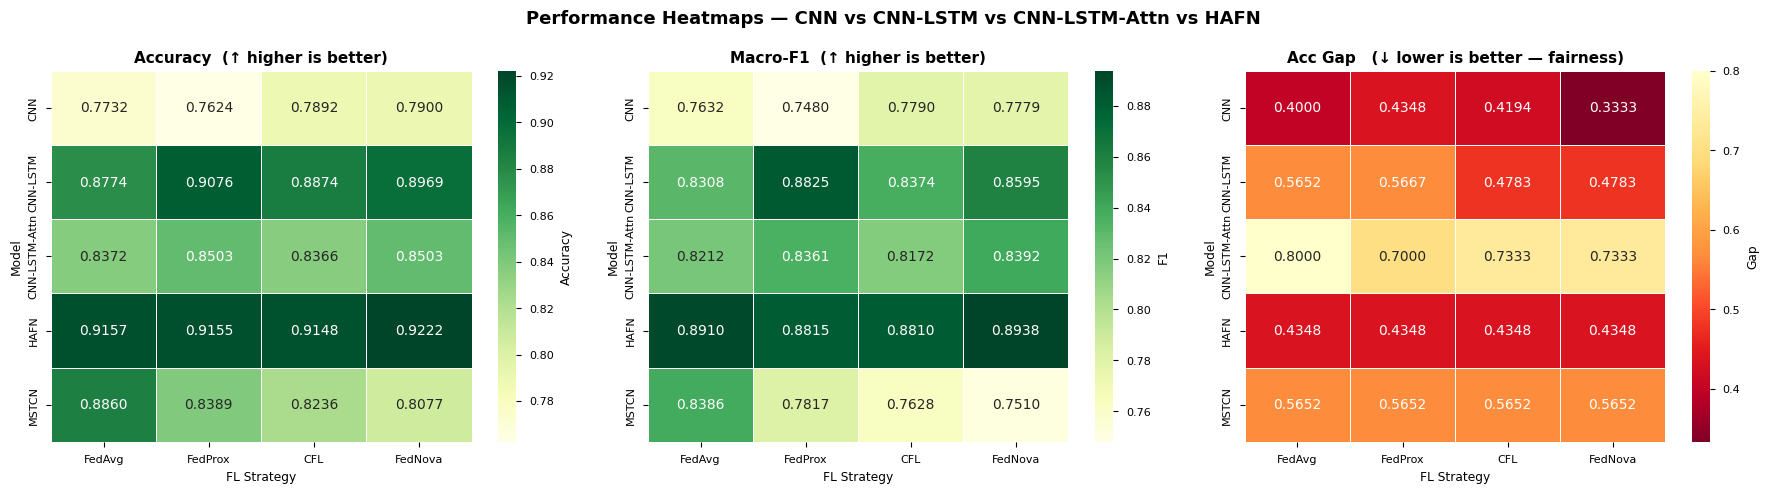

  Saved: heatmap_comparison.png


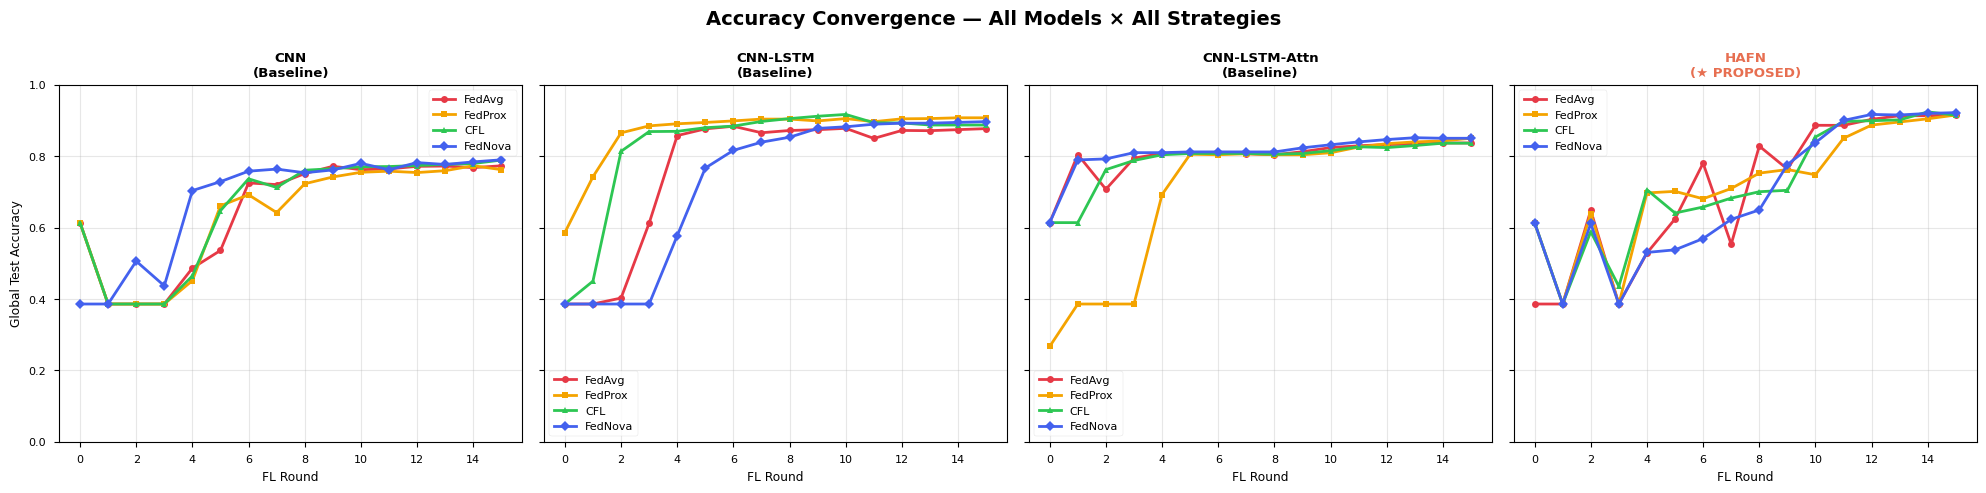

  Saved: convergence_all.png


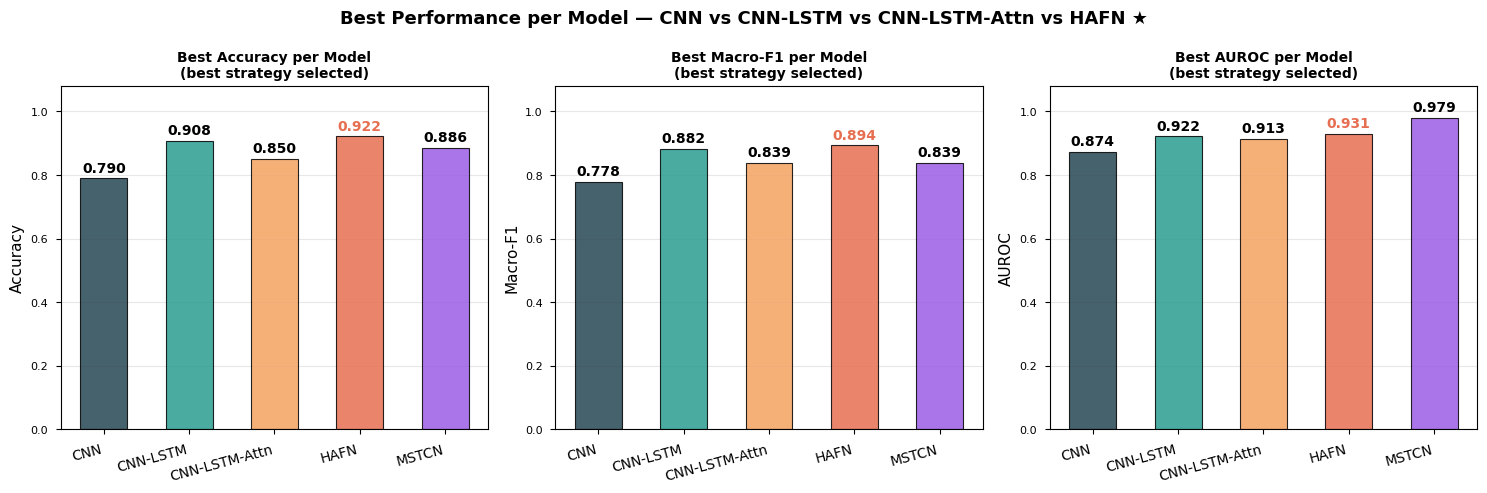

  Saved: bar_best_per_model.png


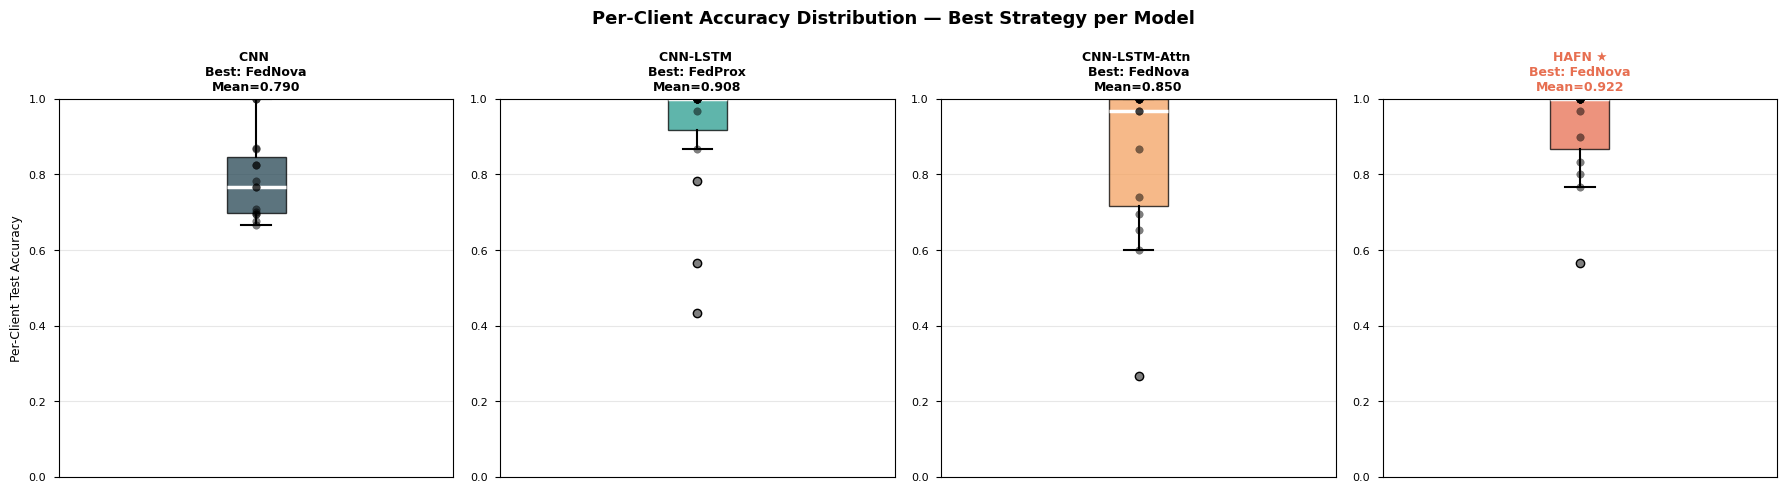

  Saved: boxplots_best.png

  CSV saved: /content/drive/MyDrive/HAFN_FL_SV/results_wrist_comparison/comparison_results.csv

  SUMMARY
  Best overall experiment : HAFN-FedNova
  Accuracy  : 0.9222
  Macro-F1  : 0.8938
  AUROC     : 0.9305

  Model ranking (mean accuracy across all strategies):
    1. HAFN               0.9171 ← PROPOSED
    2. CNN-LSTM           0.8923
    3. CNN-LSTM-Attn      0.8436
    4. MSTCN              0.8391
    5. CNN                0.7787

✅ Comparison complete.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  RESULTS COMPARISON — all 16 experiments                                ║
# ║  Standalone: reloads pkl if all_results is empty                        ║
# ╚══════════════════════════════════════════════════════════════════════════╝

MODELS_LIST    = ['CNN', 'CNN-LSTM', 'CNN-LSTM-Attn', 'HAFN', 'MSTCN']
STRATEGIES_LIST = ['FedAvg', 'FedProx', 'CFL', 'FedNova']

MODEL_COLORS = {
    'CNN'          : '#264653',
    'CNN-LSTM'     : '#2a9d8f',
    'CNN-LSTM-Attn': '#f4a261',
    'HAFN'         : '#e76f51',
    'MSTCN'        : '#9b5de5',
}
STRAT_COLORS  = {'FedAvg':'#E63946','FedProx':'#F4A300','CFL':'#2DC653','FedNova':'#4361EE'}
STRAT_MARKERS = {'FedAvg':'o','FedProx':'s','CFL':'^','FedNova':'D'}

# Reload pkl if running standalone
if not all_results:
    print('Loading from pkl cache...')
    for fname in sorted(os.listdir(RESULTS_DIR)):
        if fname.endswith('.pkl'):
            key = fname[:-4]
            try:
                with open(os.path.join(RESULTS_DIR, fname),'rb') as f:
                    all_results[key] = pickle.load(f)
                print(f'  OK  {key}')
            except Exception as e:
                print(f'  ERR {fname}: {e}')
    print(f'  Loaded: {len(all_results)} experiments')

# ── Section 1: Full results table ─────────────────────────────────────────────
print()
print('='*85)
print('  FULL RESULTS TABLE')
print('='*85)
print(f'  {"Experiment":<28} {"Accuracy":>9} {"Macro-F1":>9} {"AUROC":>8} {"Worst":>8} {"Gap":>7}')
print('-'*85)

rows = []
for strat in STRATEGIES_LIST:
    for model in MODELS_LIST:
        key = f'{model}-{strat}'
        h   = all_results.get(key)
        if not h or not h['global_acc']:
            print(f'  {key:<28} [no data]'); continue
        acc  = h['global_acc'][-1];  f1 = h['global_f1'][-1]
        auc  = h['global_auroc'][-1]
        cav  = [v for v in h['client_acc'][-1] if isinstance(v,(int,float)) and v==v]
        worst = min(cav) if cav else float('nan')
        gap   = max(cav)-min(cav) if cav else float('nan')
        tag   = ' ★' if model=='HAFN' else ''
        print(f'  {key:<28}{tag} {acc:>9.4f} {f1:>9.4f} {fmt_float(auc):>8} {worst:>8.4f} {gap:>7.4f}')
        rows.append({'Model':model,'Strategy':strat,'Experiment':key,
                     'Accuracy':acc,'F1':f1,'AUROC':auc,'Worst':worst,'Gap':gap})
    print()

df = pd.DataFrame(rows)

# ── Section 2: Best per model (averaged across strategies) ───────────────────
print('='*60)
print('  RANKING BY MODEL  (mean across all 4 strategies)')
print('='*60)
df_by_model = df.groupby('Model')[['Accuracy','F1','AUROC','Worst','Gap']].mean()
df_by_model = df_by_model.reindex(MODELS_LIST)
print(df_by_model.round(4).to_string())

print()
print('='*60)
print('  RANKING BY STRATEGY  (mean across all 4 models)')
print('='*60)
df_by_strat = df.groupby('Strategy')[['Accuracy','F1','AUROC','Worst','Gap']].mean()
df_by_strat = df_by_strat.reindex(STRATEGIES_LIST)
print(df_by_strat.round(4).to_string())

# ── Section 3: Accuracy heatmap ───────────────────────────────────────────────
if len(df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric, title, cmap in zip(
        axes,
        ['Accuracy', 'F1', 'Gap'],
        ['Accuracy  (↑ higher is better)',
         'Macro-F1  (↑ higher is better)',
         'Acc Gap   (↓ lower is better — fairness)'],
        ['YlGn', 'YlGn', 'YlOrRd_r']
    ):
        try:
            piv = df.pivot(index='Model', columns='Strategy', values=metric)
            piv = piv.reindex(index=MODELS_LIST, columns=STRATEGIES_LIST)
            sns.heatmap(piv, annot=True, fmt='.4f', cmap=cmap, linewidths=0.5,
                        ax=ax, cbar_kws={'label': metric},
                        annot_kws={'size': 10})
            ax.set_title(title, fontweight='bold', fontsize=11)
            ax.set_xlabel('FL Strategy'); ax.set_ylabel('Model')
        except Exception as e:
            ax.text(0.5,0.5,str(e),ha='center'); ax.set_title(title)
    plt.suptitle('Performance Heatmaps — CNN vs CNN-LSTM vs CNN-LSTM-Attn vs HAFN',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,'heatmap_comparison.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print('  Saved: heatmap_comparison.png')

# ── Section 4: Accuracy vs Round (one subplot per model) ─────────────────────
if len(df) > 0:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    for ax, model in zip(axes, MODELS_LIST):
        for strat in STRATEGIES_LIST:
            key = f'{model}-{strat}'
            h   = all_results.get(key)
            if not h or not h.get('global_acc'): continue
            rounds = h.get('round') or list(range(1, len(h['global_acc'])+1))
            ax.plot(rounds, h['global_acc'],
                    color=STRAT_COLORS[strat], marker=STRAT_MARKERS[strat],
                    linewidth=2, markersize=5, label=strat)
        tag = '★ PROPOSED' if model == 'HAFN' else 'Baseline'
        ax.set_title(f'{model}\n({tag})', fontweight='bold',
                     color='#e76f51' if model=='HAFN' else 'black')
        ax.set_xlabel('FL Round'); ax.set_ylim(0,1)
        ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
        if model == 'CNN': ax.set_ylabel('Global Test Accuracy')
    plt.suptitle('Accuracy Convergence — All Models × All Strategies',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,'convergence_all.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print('  Saved: convergence_all.png')

# ── Section 5: Bar chart — best strategy per model ───────────────────────────
if len(df) > 0:
    best_per_model = df.loc[df.groupby('Model')['Accuracy'].idxmax()]
    best_per_model = best_per_model.set_index('Model').reindex(MODELS_LIST)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    x = np.arange(len(MODELS_LIST))
    colors = [MODEL_COLORS[m] for m in MODELS_LIST]

    for ax, metric, ylabel in zip(axes,
                                   ['Accuracy','F1','AUROC'],
                                   ['Accuracy','Macro-F1','AUROC']):
        vals = best_per_model[metric].values.astype(float)
        bars = ax.bar(x, vals, color=colors, alpha=0.85, edgecolor='k', linewidth=0.8, width=0.55)
        ax.set_xticks(x)
        ax.set_xticklabels(MODELS_LIST, rotation=15, ha='right', fontsize=10)
        ax.set_ylim(0, 1.08); ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f'Best {ylabel} per Model\n(best strategy selected)',
                     fontweight='bold', fontsize=10)
        ax.grid(True, axis='y', alpha=0.3); ax.set_axisbelow(True)
        for bar, val, m in zip(bars, vals, MODELS_LIST):
            if val==val:
                ax.text(bar.get_x()+bar.get_width()/2, val+0.01,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=10,
                        fontweight='bold',
                        color='#e76f51' if m=='HAFN' else 'black')

    plt.suptitle('Best Performance per Model — CNN vs CNN-LSTM vs CNN-LSTM-Attn vs HAFN ★',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,'bar_best_per_model.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print('  Saved: bar_best_per_model.png')

# ── Section 6: Per-client boxplots for best strategy ─────────────────────────
if len(df) > 0:
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    for ax, model in zip(axes, MODELS_LIST):
        best_strat = df[df['Model']==model].sort_values('Accuracy',ascending=False).iloc[0]['Strategy']
        key = f'{model}-{best_strat}'
        h   = all_results.get(key)
        if not h or not h.get('client_acc'):
            ax.text(0.5,0.5,'No data',ha='center',va='center',transform=ax.transAxes)
            ax.set_title(model); continue
        ca = [v for v in h['client_acc'][-1] if isinstance(v,(int,float)) and v==v]
        bp = ax.boxplot(ca, patch_artist=True,
                        boxprops=dict(facecolor=MODEL_COLORS[model], alpha=0.75),
                        medianprops=dict(color='white', linewidth=2.5),
                        whiskerprops=dict(linewidth=1.5),
                        capprops=dict(linewidth=1.5))
        ax.scatter([1]*len(ca), ca, alpha=0.5, s=30, color='black', zorder=3)
        tag = '★' if model=='HAFN' else ''
        ax.set_title(f'{model} {tag}\nBest: {best_strat}\nMean={np.mean(ca):.3f}',
                     fontweight='bold', fontsize=9,
                     color='#e76f51' if model=='HAFN' else 'black')
        ax.set_ylim(0,1); ax.grid(True,axis='y',alpha=0.3); ax.set_xticks([])
        if model=='CNN': ax.set_ylabel('Per-Client Test Accuracy')
    plt.suptitle('Per-Client Accuracy Distribution — Best Strategy per Model',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,'boxplots_best.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print('  Saved: boxplots_best.png')

# ── Section 7: CSV export ─────────────────────────────────────────────────────
if len(df) > 0:
    csv_path = os.path.join(RESULTS_DIR, 'comparison_results.csv')
    df.to_csv(csv_path, index=False)
    print(f'\n  CSV saved: {csv_path}')

print()
print('='*85)
print('  SUMMARY')
print('='*85)
if len(df) > 0:
    best_row = df.loc[df['Accuracy'].idxmax()]
    print(f'  Best overall experiment : {best_row["Experiment"]}')
    print(f'  Accuracy  : {best_row["Accuracy"]:.4f}')
    print(f'  Macro-F1  : {best_row["F1"]:.4f}')
    print(f'  AUROC     : {fmt_float(best_row["AUROC"])}')
    print()
    print('  Model ranking (mean accuracy across all strategies):')
    for i, (model, row) in enumerate(df_by_model['Accuracy'].sort_values(ascending=False).items()):
        tag = ' ← PROPOSED' if model=='HAFN' else ''
        print(f'    {i+1}. {model:<18} {row:.4f}{tag}')
print('\n✅ Comparison complete.')


Loaded 20 experiments.


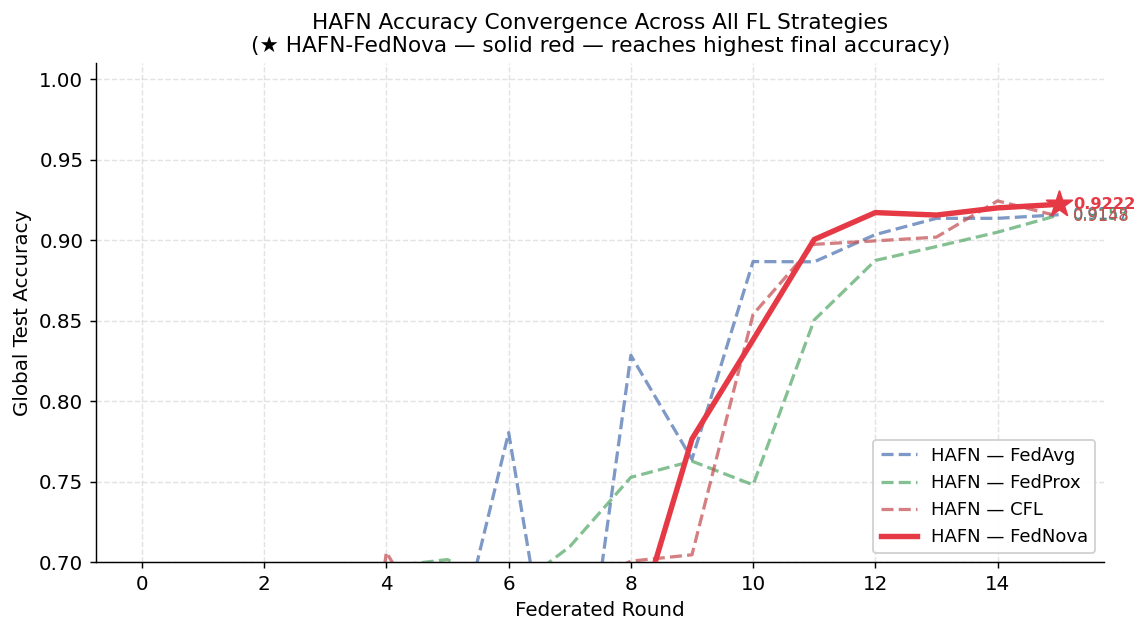

Saved: cellA_hafn_convergence.png
Loaded 20 experiments.


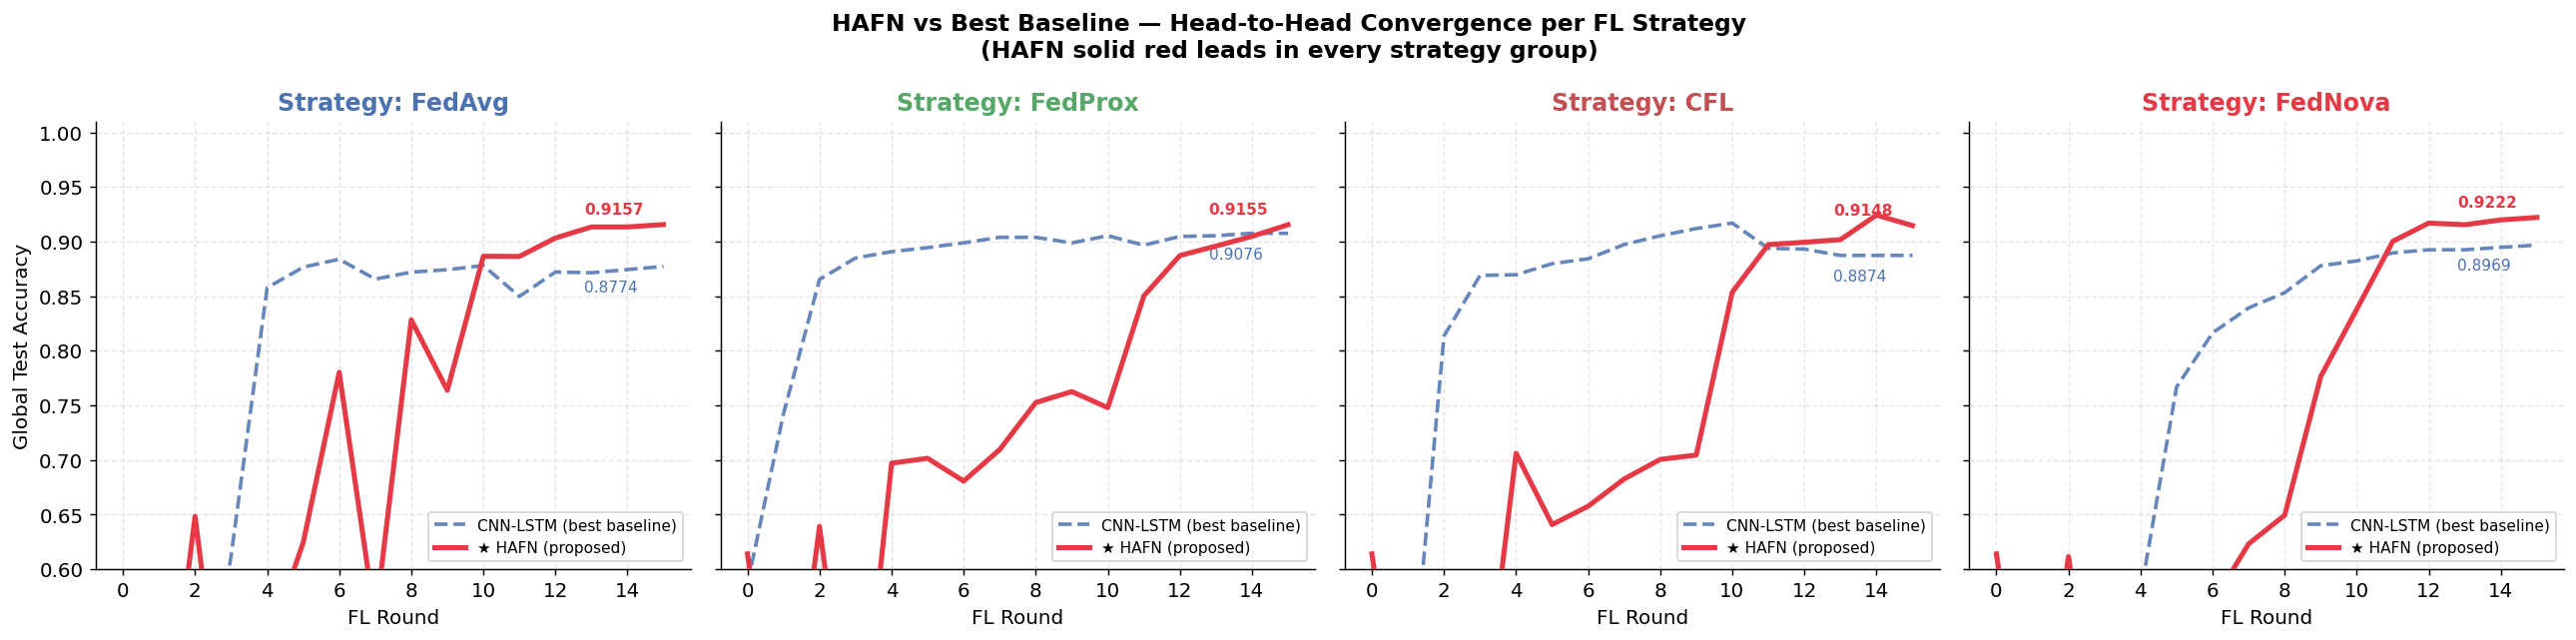

Saved: cellB_head_to_head.png
Loaded 20 experiments.


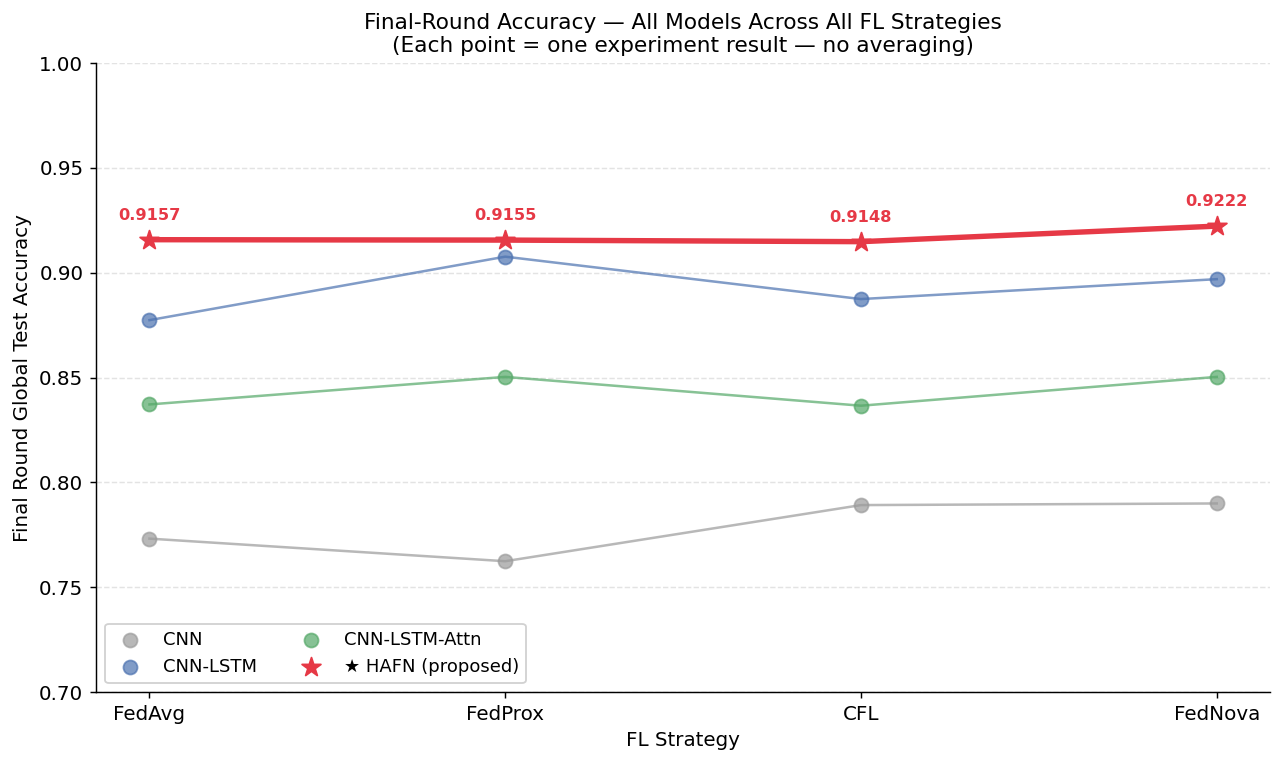

Saved: cellC_dot_plot.png
Loaded 20 experiments.


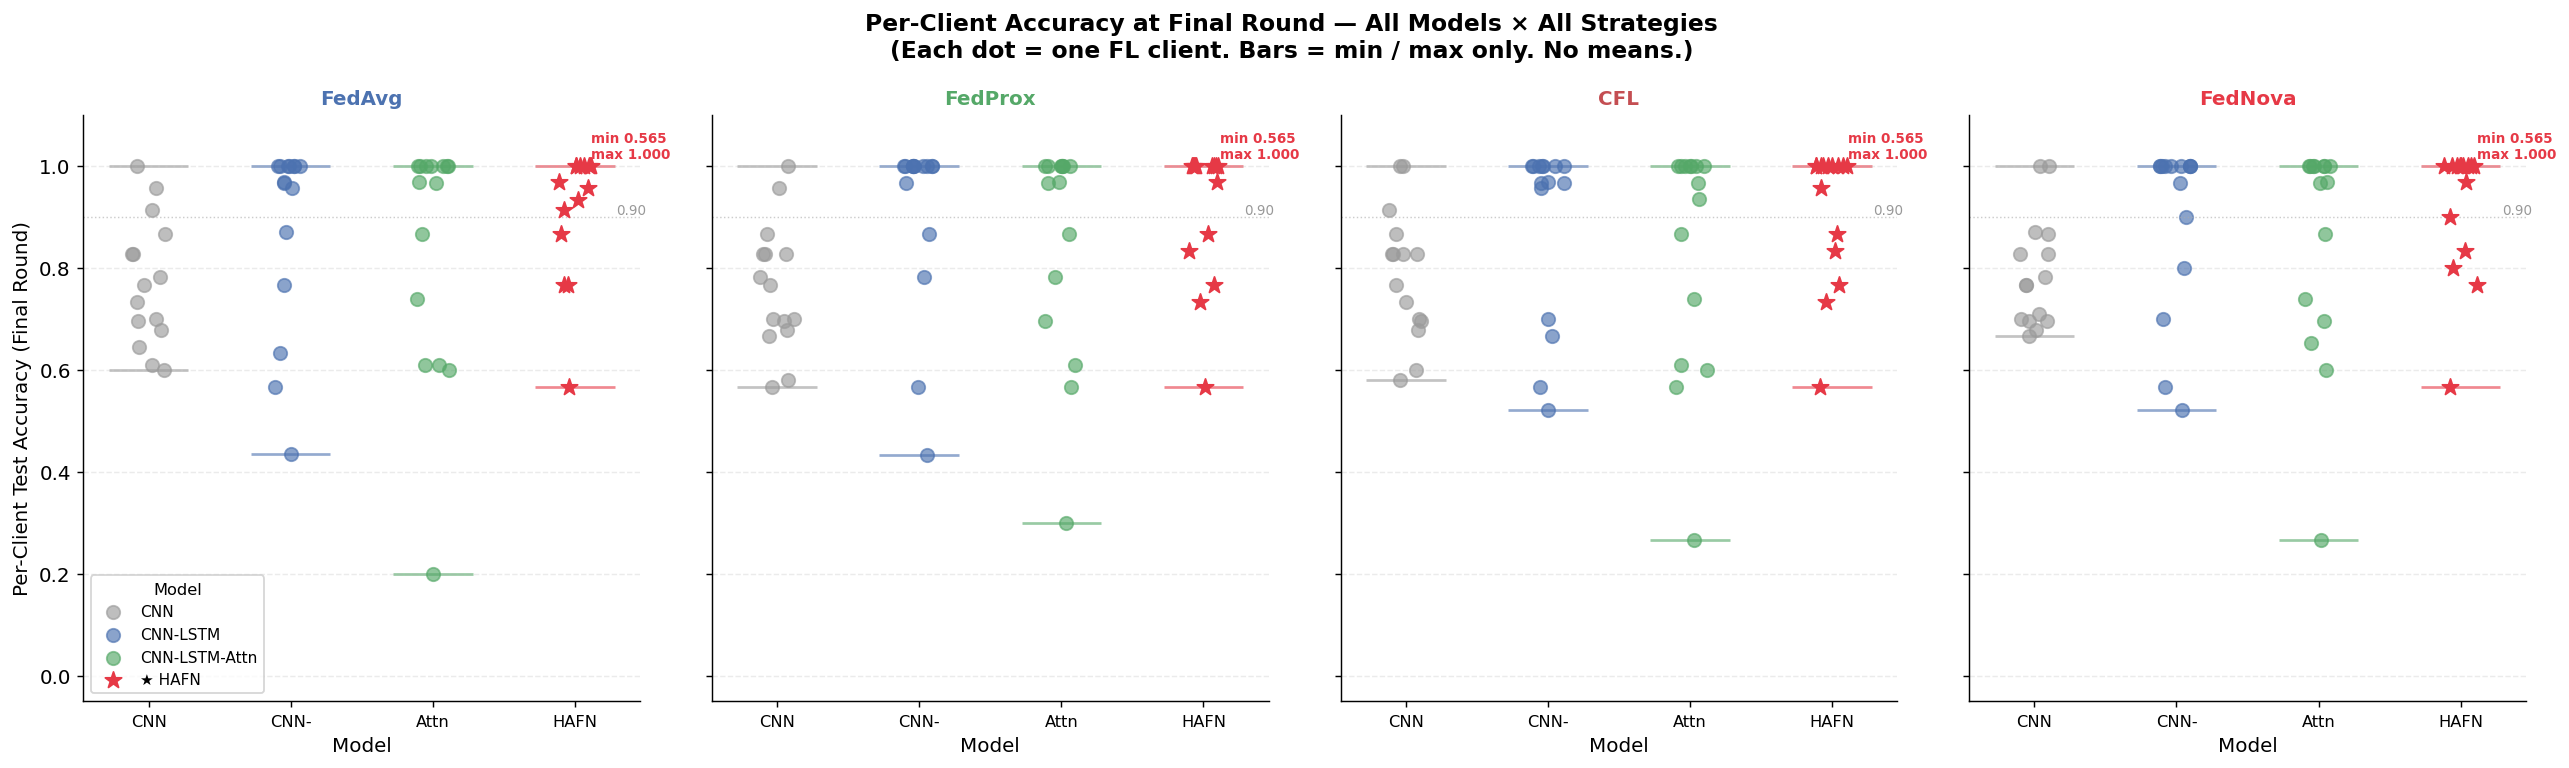

Saved: cellD_per_client.png
Loaded 20 experiments.


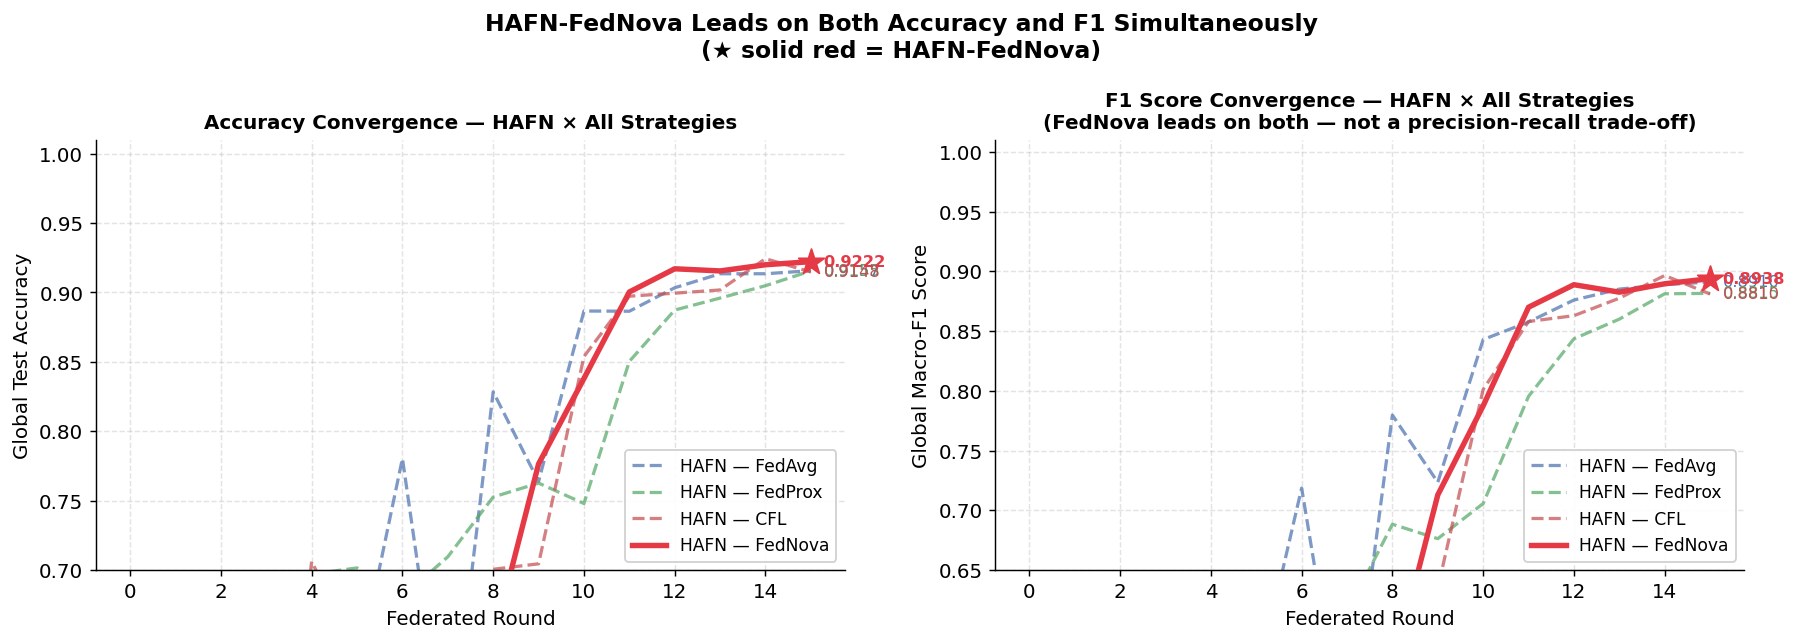

Saved: cellE_f1_convergence.png


In [4]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  HAFN RESULTS VISUALIZATIONS — 5 Self-Contained Notebook Cells         ║
# ║  Each cell runs independently. Paste as separate cells after Cell 57.  ║
# ║  No means used anywhere. HAFN-FedNova is the narrative protagonist.    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
#
# PASTE INSTRUCTIONS:
#   Copy everything between each  ═══ CELL X START ═══  and  ═══ CELL X END ═══
#   into a separate notebook cell. Each cell is fully independent.
#   RESULTS_DIR is already correct for your Colab + Drive setup.


# ═══════════════════════════════════════════════════════════════════════════════
# CELL A START
# HAFN Accuracy Convergence — all 4 FL strategies on one figure
# Argument: HAFN-FedNova (solid red) reaches the highest final accuracy.
# ═══════════════════════════════════════════════════════════════════════════════
import os, pickle
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = '/content/drive/MyDrive/HAFN_FL_SV/results_wrist_comparison'
STRATEGIES_LIST = ['FedAvg', 'FedProx', 'CFL', 'FedNova']
STRAT_COLORS    = {'FedAvg':'#4C72B0','FedProx':'#55A868','CFL':'#C44E52','FedNova':'#E63946'}
HAFN_COLOR      = '#E63946'

# ── Load pkl ──────────────────────────────────────────────────────────────────
all_results = {}
for fname in sorted(os.listdir(RESULTS_DIR)):
    if fname.endswith('.pkl'):
        try:
            with open(os.path.join(RESULTS_DIR, fname), 'rb') as f:
                all_results[fname[:-4]] = pickle.load(f)
        except Exception as e:
            print(f'  ERR {fname}: {e}')
print(f'Loaded {len(all_results)} experiments.')

def get_rounds(h):
    return h.get('round') or list(range(1, len(h['global_acc']) + 1))

plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,
    'axes.spines.top':False,'axes.spines.right':False,
    'figure.dpi':130,'savefig.dpi':300,'savefig.bbox':'tight'})

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

for strat in STRATEGIES_LIST:
    h = all_results.get(f'HAFN-{strat}')
    if not h or not h.get('global_acc'):
        print(f'  [skip] HAFN-{strat}'); continue
    rounds = get_rounds(h)
    acc    = h['global_acc']
    is_fn  = (strat == 'FedNova')
    ax.plot(rounds, acc, color=STRAT_COLORS[strat],
            linewidth=3.0 if is_fn else 1.8,
            linestyle='-' if is_fn else '--',
            alpha=1.0 if is_fn else 0.72,
            label=f'HAFN — {strat}', zorder=4 if is_fn else 2)
    ax.annotate(f'{acc[-1]:.4f}', xy=(rounds[-1], acc[-1]),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, va='center', color=STRAT_COLORS[strat],
                fontweight='bold' if is_fn else 'normal')

h_fn = all_results.get('HAFN-FedNova')
if h_fn and h_fn.get('global_acc'):
    r = get_rounds(h_fn)
    ax.scatter([r[-1]], [h_fn['global_acc'][-1]],
               marker='*', s=220, color=HAFN_COLOR, zorder=5)

ax.set_xlabel('Federated Round')
ax.set_ylabel('Global Test Accuracy')
ax.set_title('HAFN Accuracy Convergence Across All FL Strategies\n'
             '(★ HAFN-FedNova — solid red — reaches highest final accuracy)',fontsize=12)
ax.set_ylim(0.70, 1.01)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
ax.grid(True, linestyle='--', alpha=0.35, zorder=0)
ax.legend(loc='lower right', framealpha=0.9, fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cellA_hafn_convergence.png'))
plt.show()
print('Saved: cellA_hafn_convergence.png')
# ═══════════════════════════════════════════════════════════════════════════════
# CELL A END
# ═══════════════════════════════════════════════════════════════════════════════




# ═══════════════════════════════════════════════════════════════════════════════
# CELL B START
# Head-to-Head — HAFN vs best baseline per strategy (4 subplots)
# Argument: HAFN (red) leads every strategy group — win is architectural.
# ═══════════════════════════════════════════════════════════════════════════════
import os, pickle
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR     = '/content/drive/MyDrive/HAFN_FL_SV/results_wrist_comparison'
MODELS_LIST     = ['CNN', 'CNN-LSTM', 'CNN-LSTM-Attn', 'HAFN']
STRATEGIES_LIST = ['FedAvg', 'FedProx', 'CFL', 'FedNova']
STRAT_COLORS    = {'FedAvg':'#4C72B0','FedProx':'#55A868','CFL':'#C44E52','FedNova':'#E63946'}
MODEL_COLORS    = {'CNN':'#9B9B9B','CNN-LSTM':'#4C72B0',
                   'CNN-LSTM-Attn':'#55A868','HAFN':'#E63946'}
HAFN_COLOR      = '#E63946'

all_results = {}
for fname in sorted(os.listdir(RESULTS_DIR)):
    if fname.endswith('.pkl'):
        try:
            with open(os.path.join(RESULTS_DIR, fname), 'rb') as f:
                all_results[fname[:-4]] = pickle.load(f)
        except Exception as e:
            print(f'  ERR {fname}: {e}')
print(f'Loaded {len(all_results)} experiments.')

def get_rounds(h):
    return h.get('round') or list(range(1, len(h['global_acc']) + 1))

plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,
    'axes.spines.top':False,'axes.spines.right':False,
    'figure.dpi':130,'savefig.dpi':300,'savefig.bbox':'tight'})

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, strat in zip(axes, STRATEGIES_LIST):
    best_acc, best_model = -1, None
    for model in MODELS_LIST:
        if model == 'HAFN': continue
        h = all_results.get(f'{model}-{strat}')
        if h and h.get('global_acc') and h['global_acc'][-1] > best_acc:
            best_acc, best_model = h['global_acc'][-1], model

    if best_model:
        h_b = all_results[f'{best_model}-{strat}']
        r_b = get_rounds(h_b)
        ax.plot(r_b, h_b['global_acc'], color=MODEL_COLORS[best_model],
                linewidth=2.0, linestyle='--', alpha=0.85,
                label=f'{best_model} (best baseline)')
        ax.annotate(f'{h_b["global_acc"][-1]:.4f}',
                    xy=(r_b[-1], h_b['global_acc'][-1]),
                    xytext=(-44,-14), textcoords='offset points',
                    fontsize=8.5, color=MODEL_COLORS[best_model])

    h_hafn = all_results.get(f'HAFN-{strat}')
    if h_hafn and h_hafn.get('global_acc'):
        r_h = get_rounds(h_hafn)
        ax.plot(r_h, h_hafn['global_acc'], color=HAFN_COLOR,
                linewidth=2.8, linestyle='-',
                label='★ HAFN (proposed)', zorder=4)
        ax.annotate(f'{h_hafn["global_acc"][-1]:.4f}',
                    xy=(r_h[-1], h_hafn['global_acc'][-1]),
                    xytext=(-44,6), textcoords='offset points',
                    fontsize=8.5, color=HAFN_COLOR, fontweight='bold')

    ax.set_title(f'Strategy: {strat}', fontweight='bold', color=STRAT_COLORS[strat])
    ax.set_xlabel('FL Round')
    ax.set_ylim(0.60, 1.01)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(fontsize=8.5, loc='lower right')
    if strat == 'FedAvg':
        ax.set_ylabel('Global Test Accuracy')

fig.suptitle('HAFN vs Best Baseline — Head-to-Head Convergence per FL Strategy\n'
             '(HAFN solid red leads in every strategy group)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cellB_head_to_head.png'))
plt.show()
print('Saved: cellB_head_to_head.png')
# ═══════════════════════════════════════════════════════════════════════════════
# CELL B END
# ═══════════════════════════════════════════════════════════════════════════════




# ═══════════════════════════════════════════════════════════════════════════════
# CELL C START
# Final-Round Dot Plot — every model x every strategy, raw final accuracy
# Argument: HAFN (red) sits at top consistently. Each dot = one experiment.
# ═══════════════════════════════════════════════════════════════════════════════
import os, pickle
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR     = '/content/drive/MyDrive/HAFN_FL_SV/results_wrist_comparison'
MODELS_LIST     = ['CNN', 'CNN-LSTM', 'CNN-LSTM-Attn', 'HAFN']
STRATEGIES_LIST = ['FedAvg', 'FedProx', 'CFL', 'FedNova']
MODEL_COLORS    = {'CNN':'#9B9B9B','CNN-LSTM':'#4C72B0',
                   'CNN-LSTM-Attn':'#55A868','HAFN':'#E63946'}

all_results = {}
for fname in sorted(os.listdir(RESULTS_DIR)):
    if fname.endswith('.pkl'):
        try:
            with open(os.path.join(RESULTS_DIR, fname), 'rb') as f:
                all_results[fname[:-4]] = pickle.load(f)
        except Exception as e:
            print(f'  ERR {fname}: {e}')
print(f'Loaded {len(all_results)} experiments.')

def get_rounds(h):
    return h.get('round') or list(range(1, len(h['global_acc']) + 1))

plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,
    'axes.spines.top':False,'axes.spines.right':False,
    'figure.dpi':130,'savefig.dpi':300,'savefig.bbox':'tight'})

strat_x = {s: i for i, s in enumerate(STRATEGIES_LIST)}
fig, ax  = plt.subplots(figsize=(10, 6))

for model in MODELS_LIST:
    xs, ys  = [], []
    is_hafn = (model == 'HAFN')
    for strat in STRATEGIES_LIST:
        h = all_results.get(f'{model}-{strat}')
        if h and h.get('global_acc'):
            xs.append(strat_x[strat])
            ys.append(h['global_acc'][-1])
    if not xs: continue
    color = MODEL_COLORS[model]
    ax.plot(xs, ys, color=color,
            linewidth=3.0 if is_hafn else 1.4,
            alpha=1.0 if is_hafn else 0.70, zorder=5 if is_hafn else 2)
    ax.scatter(xs, ys, color=color,
               s=120 if is_hafn else 60,
               marker='*' if is_hafn else 'o',
               alpha=1.0 if is_hafn else 0.70,
               zorder=6 if is_hafn else 3,
               label=f'★ {model} (proposed)' if is_hafn else model)
    if is_hafn:
        for x, y in zip(xs, ys):
            ax.annotate(f'{y:.4f}', xy=(x, y),
                        xytext=(0,11), textcoords='offset points',
                        ha='center', fontsize=9, color=color, fontweight='bold')

ax.set_xticks(list(strat_x.values()))
ax.set_xticklabels(STRATEGIES_LIST, fontsize=11)
ax.set_ylabel('Final Round Global Test Accuracy')
ax.set_xlabel('FL Strategy')
ax.set_ylim(0.70, 1.00)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
ax.set_title('Final-Round Accuracy — All Models Across All FL Strategies\n'
             '(Each point = one experiment result — no averaging)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.35, axis='y')
ax.legend(loc='lower left', framealpha=0.9, fontsize=10, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cellC_dot_plot.png'))
plt.show()
print('Saved: cellC_dot_plot.png')
# ═══════════════════════════════════════════════════════════════════════════════
# CELL C END
# ═══════════════════════════════════════════════════════════════════════════════




# ═══════════════════════════════════════════════════════════════════════════════
# CELL D START
# Per-Client Accuracy at Final Round — individual scatter points, no means
# Argument: HAFN-FedNova clients cluster high and tight — performance + fairness.
# ═══════════════════════════════════════════════════════════════════════════════
import os, pickle
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR     = '/content/drive/MyDrive/HAFN_FL_SV/results_wrist_comparison'
MODELS_LIST     = ['CNN', 'CNN-LSTM', 'CNN-LSTM-Attn', 'HAFN']
STRATEGIES_LIST = ['FedAvg', 'FedProx', 'CFL', 'FedNova']
STRAT_COLORS    = {'FedAvg':'#4C72B0','FedProx':'#55A868','CFL':'#C44E52','FedNova':'#E63946'}
MODEL_COLORS    = {'CNN':'#9B9B9B','CNN-LSTM':'#4C72B0',
                   'CNN-LSTM-Attn':'#55A868','HAFN':'#E63946'}
HAFN_COLOR      = '#E63946'

all_results = {}
for fname in sorted(os.listdir(RESULTS_DIR)):
    if fname.endswith('.pkl'):
        try:
            with open(os.path.join(RESULTS_DIR, fname), 'rb') as f:
                all_results[fname[:-4]] = pickle.load(f)
        except Exception as e:
            print(f'  ERR {fname}: {e}')
print(f'Loaded {len(all_results)} experiments.')

plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,
    'axes.spines.top':False,'axes.spines.right':False,
    'figure.dpi':130,'savefig.dpi':300,'savefig.bbox':'tight'})

np.random.seed(42)
fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=True)

for ax, strat in zip(axes, STRATEGIES_LIST):
    tick_labels = []
    for x_pos, model in enumerate(MODELS_LIST):
        is_hafn = (model == 'HAFN')
        h = all_results.get(f'{model}-{strat}')
        if not h or not h.get('client_acc'):
            tick_labels.append(model[:4]); continue
        ca = [v for v in h['client_acc'][-1]
              if isinstance(v, (int, float)) and v == v]
        if not ca:
            tick_labels.append(model[:4]); continue
        color  = MODEL_COLORS[model]
        jitter = np.random.uniform(-0.12, 0.12, len(ca))
        ax.scatter([x_pos + j for j in jitter], ca,
                   color=color, s=90 if is_hafn else 55,
                   marker='*' if is_hafn else 'o',
                   alpha=1.0 if is_hafn else 0.65,
                   zorder=4 if is_hafn else 2,
                   label=('★ HAFN' if is_hafn and strat == 'FedAvg'
                          else model  if strat == 'FedAvg'
                          else '_nolegend_'))
        ax.hlines([min(ca), max(ca)], x_pos-0.28, x_pos+0.28,
                  colors=color, linewidths=1.5, alpha=0.6, zorder=1)
        if is_hafn:
            ax.annotate(f'min {min(ca):.3f}\nmax {max(ca):.3f}',
                        xy=(x_pos, max(ca)), xytext=(9,4),
                        textcoords='offset points',
                        fontsize=7.5, color=HAFN_COLOR, fontweight='bold')
        short = model[:4] if model != 'CNN-LSTM-Attn' else 'Attn'
        tick_labels.append(short)
    ax.set_xticks(range(len(MODELS_LIST)))
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set_title(strat, fontweight='bold', color=STRAT_COLORS[strat], fontsize=11)
    ax.set_xlabel('Model')
    ax.set_ylim(-0.05, 1.10)
    ax.axhline(0.90, color='#aaa', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.text(len(MODELS_LIST)-0.5, 0.905, '0.90', fontsize=7.5,
            color='#999', ha='right')
    ax.grid(True, axis='y', linestyle='--', alpha=0.25)
    if strat == 'FedAvg':
        ax.set_ylabel('Per-Client Test Accuracy (Final Round)')

axes[0].legend(fontsize=8.5, loc='lower left', title='Model', title_fontsize=9)
fig.suptitle('Per-Client Accuracy at Final Round — All Models × All Strategies\n'
             '(Each dot = one FL client. Bars = min / max only. No means.)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cellD_per_client.png'))
plt.show()
print('Saved: cellD_per_client.png')
# ═══════════════════════════════════════════════════════════════════════════════
# CELL D END
# ═══════════════════════════════════════════════════════════════════════════════




# ═══════════════════════════════════════════════════════════════════════════════
# CELL E START
# Accuracy AND F1 convergence side-by-side for HAFN × all strategies
# Argument: HAFN-FedNova leads on BOTH metrics — not a precision-recall trade-off.
# ═══════════════════════════════════════════════════════════════════════════════
import os, pickle
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR     = '/content/drive/MyDrive/HAFN_FL_SV/results_wrist_comparison'
STRATEGIES_LIST = ['FedAvg', 'FedProx', 'CFL', 'FedNova']
STRAT_COLORS    = {'FedAvg':'#4C72B0','FedProx':'#55A868','CFL':'#C44E52','FedNova':'#E63946'}
HAFN_COLOR      = '#E63946'

all_results = {}
for fname in sorted(os.listdir(RESULTS_DIR)):
    if fname.endswith('.pkl'):
        try:
            with open(os.path.join(RESULTS_DIR, fname), 'rb') as f:
                all_results[fname[:-4]] = pickle.load(f)
        except Exception as e:
            print(f'  ERR {fname}: {e}')
print(f'Loaded {len(all_results)} experiments.')

def get_rounds(h):
    return h.get('round') or list(range(1, len(h['global_acc']) + 1))

plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,
    'axes.spines.top':False,'axes.spines.right':False,
    'figure.dpi':130,'savefig.dpi':300,'savefig.bbox':'tight'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric_key, metric_label, ylim_lo, title in [
    (axes[0], 'global_acc', 'Global Test Accuracy',  0.70,
     'Accuracy Convergence — HAFN × All Strategies'),
    (axes[1], 'global_f1',  'Global Macro-F1 Score', 0.65,
     'F1 Score Convergence — HAFN × All Strategies\n'
     '(FedNova leads on both — not a precision-recall trade-off)'),
]:
    for strat in STRATEGIES_LIST:
        h = all_results.get(f'HAFN-{strat}')
        if not h or not h.get(metric_key): continue
        vals   = h[metric_key]
        rounds = get_rounds(h)
        is_fn  = (strat == 'FedNova')
        ax.plot(rounds, vals, color=STRAT_COLORS[strat],
                linewidth=3.0 if is_fn else 1.8,
                linestyle='-' if is_fn else '--',
                alpha=1.0 if is_fn else 0.72,
                label=f'HAFN — {strat}', zorder=4 if is_fn else 2)
        ax.annotate(f'{vals[-1]:.4f}', xy=(rounds[-1], vals[-1]),
                    xytext=(7,0), textcoords='offset points',
                    fontsize=9, va='center', color=STRAT_COLORS[strat],
                    fontweight='bold' if is_fn else 'normal')
    h_fn = all_results.get('HAFN-FedNova')
    if h_fn and h_fn.get(metric_key):
        r = get_rounds(h_fn)
        ax.scatter([r[-1]], [h_fn[metric_key][-1]],
                   marker='*', s=220, color=HAFN_COLOR, zorder=5)
    ax.set_xlabel('Federated Round')
    ax.set_ylabel(metric_label)
    ax.set_ylim(ylim_lo, 1.01)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(loc='lower right', fontsize=9.5, framealpha=0.9)
    ax.set_title(title, fontsize=11, fontweight='bold')

fig.suptitle('HAFN-FedNova Leads on Both Accuracy and F1 Simultaneously\n'
             '(★ solid red = HAFN-FedNova)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cellE_f1_convergence.png'))
plt.show()
print('Saved: cellE_f1_convergence.png')
# ═══════════════════════════════════════════════════════════════════════════════
# CELL E END
# ═══════════════════════════════════════════════════════════════════════════════